<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_7/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_7_%D0%A0%D0%B0%D0%B7%D0%B2%D1%91%D1%80%D1%82%D1%8B%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D1%81%D0%BE%D0%B7%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B2%D0%B5%D0%B1_%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%84%D0%B5%D0%B9%D1%81%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Лекция №7: Развёртывание моделей: создание веб-интерфейсов



## 1. ВВЕДЕНИЕ

### 1.1. От модели к инструменту: зачем психологу веб-приложение

Мы проделали огромный путь. В Лекции 2 мы научились работать с данными — опросниками, шкалами, клиническими протоколами. В Лекции 3 мы освоили очистку текста и превращение его в числа. В Лекции 5 мы познакомились с современными NLP-моделями — BERT, GPT, трансформерами. В Практике 6 мы дообучили модель классифицировать эмоции на русском языке.

**Но что дальше?** Модель есть. Она работает. Но она живёт в вашем ноутбуке, в Jupyter Notebook. Как показать её коллегам? Как дать её пациенту? Как использовать в клинике?

**Ответ:** создать **веб-интерфейс** — простое приложение, где пользователь вводит текст, нажимает кнопку и получает результат.

**Интуитивная аналогия из психотерапии:**

> Представьте, что вы разработали новый опросник для диагностики депрессии. Вы провели исследования, доказали его валидность, опубликовали статью. Но чтобы другие психологи могли им пользоваться, нужно издать бланки, написать инструкцию, распространить. Веб-приложение — это то же самое: **упаковка вашей модели в удобный инструмент**, который может использовать любой человек с доступом в интернет.

**Что мы узнаем сегодня:**

- Какие инструменты существуют для создания веб-интерфейсов (Streamlit, Gradio).
- **Пошаговую инструкцию:** как создать проект от А до Я.
- Как добавить загрузку файлов, ввод текста и вывод результатов.
- Как выложить приложение в интернет (облачный деплой).
- Этические правила использования таких приложений в психологии.
- Реальный пример полноценного приложения для психолога.

**Ключевая мысль:** создание веб-интерфейса — это **последний шаг** от идеи к реальному инструменту. Именно здесь модель перестаёт быть «игрушкой для программистов» и становится **помощником психолога**.

---

### 1.2. Актуальность для клинической психологии

В современной психологической практике всё чаще используются цифровые инструменты. Согласно данным [5], количество психологов, использующих ИИ-инструменты в работе, выросло на 40% за последние два года. Веб-приложения позволяют:

| Что даёт веб-приложение | Как это помогает психологу |
|--------------------------|---------------------------|
| **Доступность** | Пациент может использовать инструмент удалённо |
| **Стандартизация** | Все пользователи получают одинаковый опыт |
| **Автоматизация** | Модель обрабатывает текст мгновенно |
| **Сбор данных** | Можно анализировать агрегированные результаты |
| **Визуализация** | Результаты представлены в наглядной форме |

---

### 1.3. Связь с предыдущими лекциями и практикой

| Предыдущий материал | Связь с текущей темой |
|---------------------|----------------------|
| **Практика 6.** Дообучение модели классификации эмоций | Сегодня мы **упаковываем** эту модель в веб-приложение |
| **Лекция 4.** Визуализация данных | Графики matplotlib, которые мы строили, будут частью приложения |
| **Лекция 6.** Метрики качества | Мы показываем пользователю уверенность модели в предсказании |

---

### 1.4. Этический контекст

Веб-приложение делает модель **доступной** для широкого круга пользователей. Это прекрасно, но также создаёт **этические риски**. Мы обязаны:

- Предупредить пользователей, что это **не медицинская диагностика**.
- Обеспечить **конфиденциальность** данных.
- Не допустить использования модели для принятия клинических решений без контроля специалиста.

Эти вопросы мы разберём в отдельном разделе.

---



## 2. ОБЗОР ИНСТРУМЕНТОВ: STREAMLIT И GRADIO

### 2.1. Почему не нужно быть веб-разработчиком

Создание веб-сайтов обычно требует знания HTML, CSS, JavaScript, бэкенд-фреймворков. Это сложно и долго. Для полноценного сайта нужно:

1. **Фронтенд** — то, что видит пользователь (кнопки, формы, стили).
2. **Бэкенд** — серверная логика, обработка данных.
3. **База данных** — хранение информации.

**Но есть инструменты, которые позволяют создать веб-приложение на чистом Python.** Вы пишете Python-код — и он автоматически превращается в веб-страницу с кнопками, полями ввода и графиками.

**Интуитивная аналогия из психологии:**

> Представьте, что вы психолог и хотите создать опросник в Google Forms. Вы не пишете HTML-код, вы просто заполняете шаблон — и форма готова. Streamlit и Gradio — это то же самое, но для ИИ-приложений.
>
> **Аналогия с кабинетом психолога:**
> - Обычная веб-разработка — это как построить кабинет с нуля: залить фундамент, возвести стены, сделать ремонт.
> - Streamlit и Gradio — это как взять готовый кабинет с мебелью и просто расставить свои инструменты на полках.

**Преимущества такого подхода:**

| Преимущество | Объяснение |
|--------------|------------|
| **Минимум кода** | Несколько строк вместо сотен |
| **Никакого фронтенда** | Не нужно знать HTML, CSS, JavaScript |
| **Интерактивность** | Кнопки, ползунки, поля ввода — всё готово |
| **Быстрый прототип** | Можно показать результат через час работы |
| **Фокус на сути** | Вы сосредоточены на модели, а не на вёрстке |

**Интуитивная аналогия:**

> Представьте, что вы разработали новый метод диагностики. Чтобы поделиться им с коллегами, вам нужно не только описать метод, но и создать удобный инструмент для его применения. Streamlit и Gradio — это как готовые бланки опросников: вы их не создаёте с нуля, а просто заполняете.

---

### 2.2. Что такое VS Code и зачем он нужен

**Что такое VS Code:** Visual Studio Code (VS Code) — это бесплатный редактор кода, в котором мы будем писать Python-программы. Он похож на Word, но для кода.

**Интуитивная аналогия:**

> VS Code — это как кабинет психолога. В нём есть всё необходимое для работы: стол (редактор кода), шкафы для документов (проводник файлов), и вы можете настроить его под себя (установить расширения).

**Почему VS Code, а не другой редактор:**

| Редактор | Плюсы | Минусы | Для кого |
|----------|-------|--------|----------|
| **VS Code** | Бесплатный, мощный, много плагинов, работает на всех ОС | Нужно немного настроить | Для всех — идеальный выбор |
| **PyCharm** | Отличная поддержка Python, всё "из коробки" | Тяжёлый, платный (есть бесплатная версия) | Для профессиональных разработчиков |
| **Jupyter Notebook** | Интерактивный, видно результат сразу, удобно для анализа | Неудобно для больших проектов | Для экспериментов и прототипов |
| **Sublime Text** | Лёгкий, быстрый, красивый | Меньше функций, платный | Для быстрого редактирования |

**Рекомендация:** для наших целей используем **VS Code** — он бесплатный, мощный и самый популярный среди разработчиков.

---

### 2.3. Установка и настройка VS Code для работы с Python

**2.3.1. Установка VS Code**

**Пошаговая инструкция:**

1. Зайдите на сайт: https://code.visualstudio.com/
2. Нажмите "Download for Windows" (или для вашей ОС — Mac, Linux).
3. Запустите скачанный файл установки.
4. Следуйте инструкциям установщика:
   - Примите лицензионное соглашение.
   - Выберите папку для установки (можно оставить по умолчанию).
   - **Важно:** на экране "Выбор дополнительных задач" отметьте все галочки, особенно:
     - ✅ "Добавить в PATH" — чтобы можно было запускать VS Code из командной строки.
     - ✅ "Добавить контекстное меню 'Открыть с помощью Code'" — чтобы открывать папки прямо из проводника.
   - Нажмите "Установить".
5. После установки откройте VS Code.

**Что должно появиться:** окно с левой панелью (проводник) и большой областью для кода.

**2.3.2. Установка Python**

**Что такое Python:** это язык программирования, на котором мы пишем код. Нужно установить его на компьютер.

**Пошаговая инструкция:**

1. Зайдите на сайт: https://python.org/downloads/
2. Нажмите "Download Python" (последняя версия).
3. Запустите скачанный файл.
4. **Важно:** на первом экране установщика обязательно отметьте галочку **"Add Python to PATH"**!
5. Нажмите "Install Now".
6. Дождитесь завершения установки.
7. Проверьте установку: откройте командную строку (Win + R → cmd) и выполните:

```bash
python --version
# Должно вывести что-то вроде: Python 3.12.0
```

**2.3.3. Установка расширения Python для VS Code**

Расширения добавляют функциональность в VS Code. Для работы с Python нужно установить расширение от Microsoft.

**Пошаговая инструкция:**

1. Откройте VS Code.
2. Нажмите на иконку "Extensions" (расширения) в левой боковой панели (это квадратики, или нажмите Ctrl+Shift+X).
3. В строке поиска введите "Python".
4. Выберите расширение с названием "Python" от Microsoft (самое популярное, с синим логотипом).
5. Нажмите "Install".
6. После установки перезагрузите VS Code (закройте и откройте снова).

**Интуитивная аналогия:**

> Установка Python-расширения в VS Code — это как установка специализированного программного обеспечения для психолога. Без него вы можете работать, но с ним всё удобнее и быстрее.



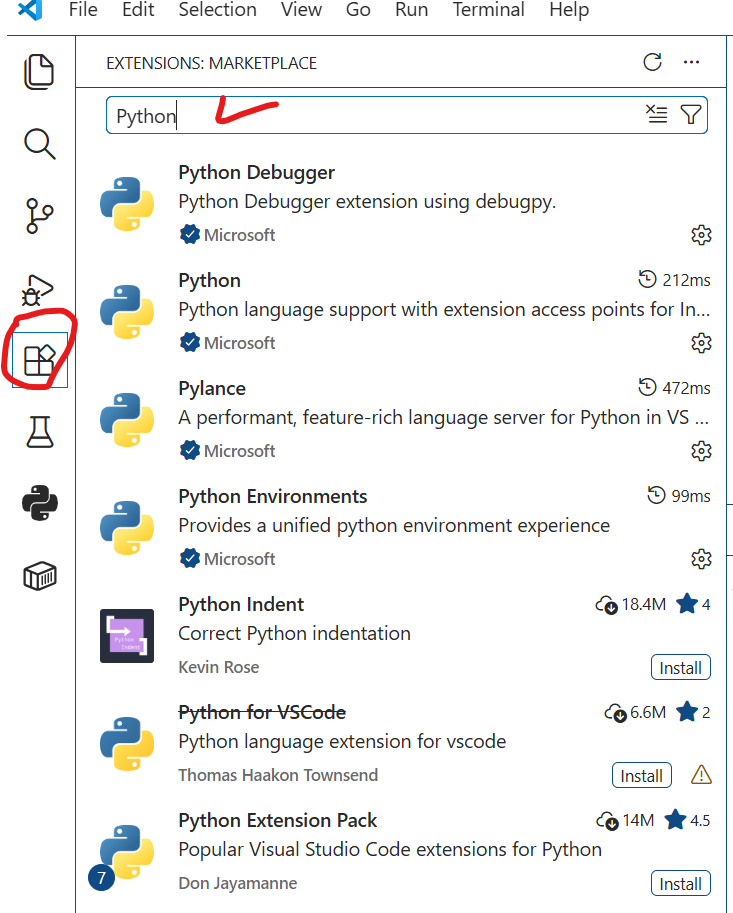



### 2.4. Создание проекта в VS Code: пошаговая инструкция

**Теперь мы готовы создать первый проект.** Это как подготовить кабинет к работе — создать папку, открыть файлы, настроить окружение.

**2.4.1. Создание папки проекта**

**Способ 1: Через проводник Windows**

1. Откройте проводник Windows (Win + E).
2. Перейдите на диск D: (или создайте папку на рабочем столе, если диска D нет).
3. Нажмите правой кнопкой мыши → Создать → Папка.
4. Назовите папку: `my_psychology_app` (можно на русском, но лучше на английском).

**Способ 2: Создание папки прямо в VS Code**

1. Откройте VS Code.
2. Нажмите "Open Folder" (или Файл → Открыть папку).
3. В открывшемся окне создайте новую папку (правой кнопкой → Создать → Папка).
4. Назовите её `my_psychology_app`.
5. Нажмите "Выбрать папку".

**Что должно появиться:** VS Code покажет вашу папку в левой панели (проводник). Пока там ничего нет.



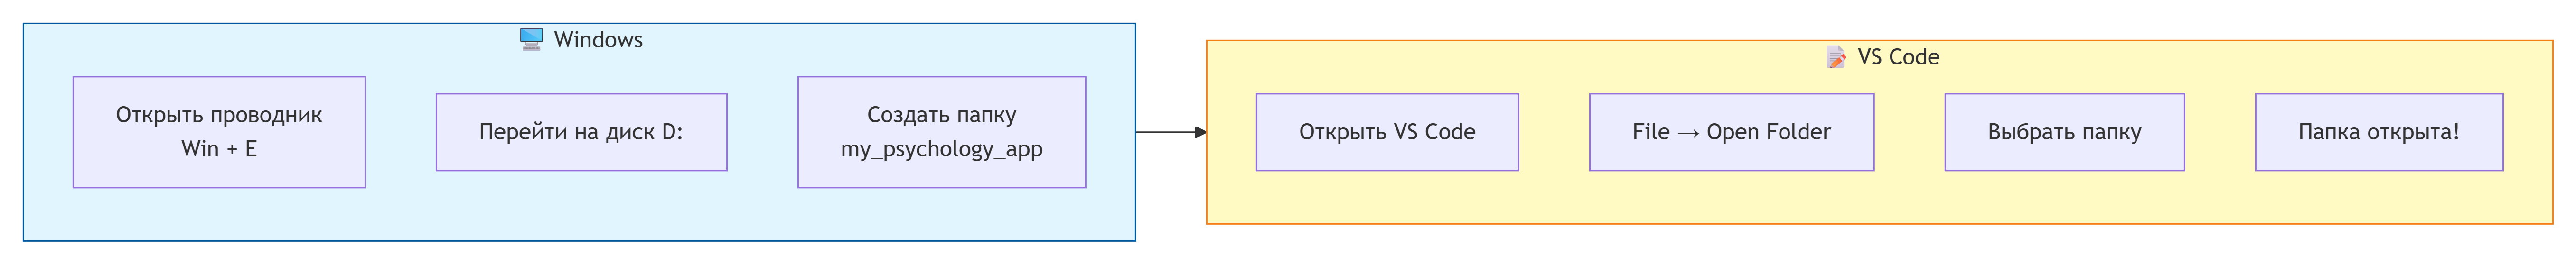

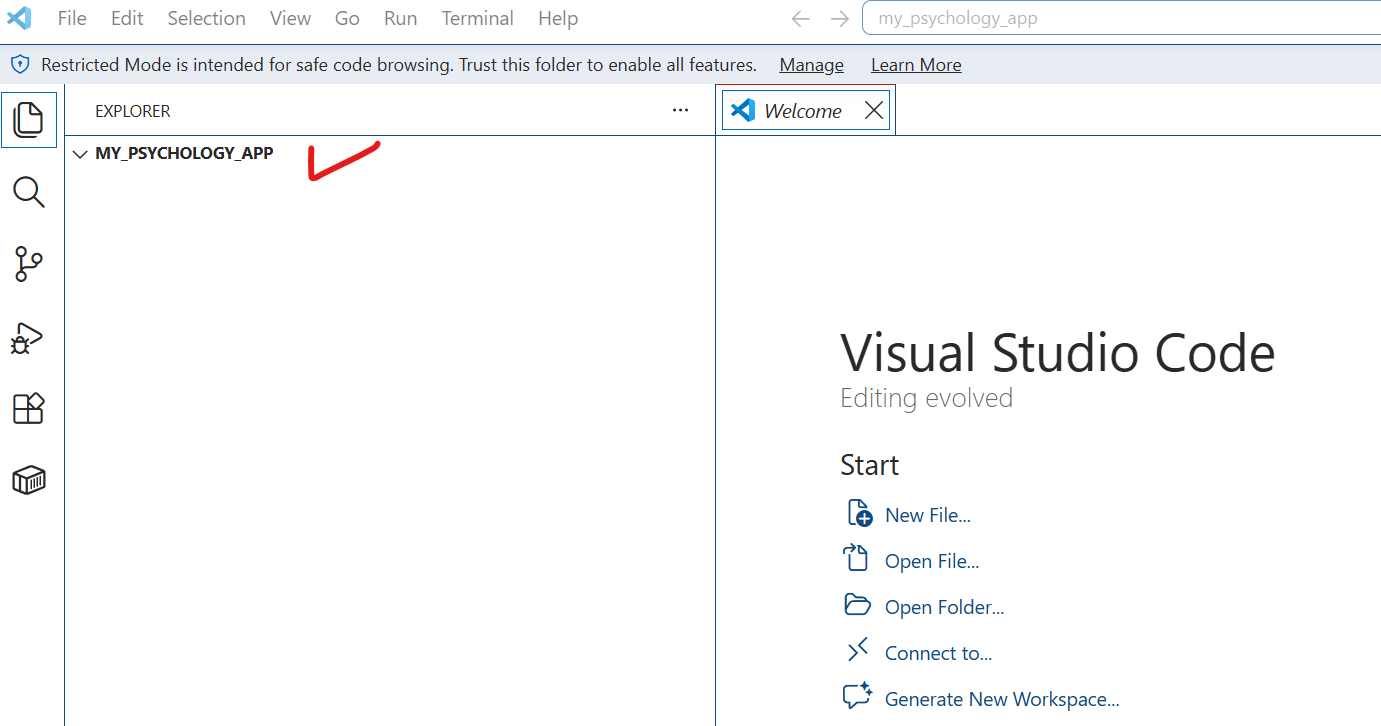



### 2.5. Streamlit — главный инструмент для полноценных приложений

**Что это:** библиотека Python, которая превращает скрипты в интерактивные веб-приложения за минуты [1]. Это как «конструктор» для создания веб-приложений без навыков веб-разработки.

**Ключевые особенности:**

- **Минимум кода** — несколько строк для полноценного приложения.
- **Никакого фронтенда** — не нужно знать HTML, CSS, JavaScript.
- **Интерактивность из коробки** — кнопки, ползунки, поля ввода, загрузка файлов.
- **Встроенная визуализация** — графики matplotlib прямо в приложении.
- **Автоматическое обновление** — при изменении кода страница перезагружается.
- **Кеширование** — тяжёлые операции выполняются один раз (`@st.cache_resource`).

**Почему Streamlit подходит психологам:**

| Причина | Объяснение |
|---------|------------|
| **Простота обучения** | Нужен только базовый Python |
| **Быстрый старт** | Можно создать приложение за 30 минут |
| **Профессиональный вид** | Приложение выглядит современно |
| **Бесплатный хостинг** | Streamlit Cloud — бесплатно для небольших проектов |
| **Сообщество** | Много примеров и готовых решений |
| **Гибкость интерфейса** | Можно создавать вкладки, боковые панели, настраивать макет |

**Интуитивная аналогия:**

> Streamlit — это как **полноценный кабинет психолога** с удобной мебелью, зоной ожидания, кабинетом для терапии. Всё уже продумано для работы, вам нужно только расставить свои инструменты.

---

### 2.6. Установка Streamlit и создание первого приложения

**2.6.1. Открытие терминала в VS Code**

Чтобы запускать команды, нам нужен терминал (командная строка) внутри VS Code.

**Как открыть терминал:**

1. В верхнем меню VS Code нажмите **Terminal** → **New Terminal**.
2. Или используйте сочетание клавиш: **Ctrl + `** (тильда — это клавиша с символом `~`).

**Что должно появиться:** внизу VS Code откроется панель с командной строкой.

**Интуитивная аналогия:**

> Терминал — это как ваш ассистент. Вы даёте ему команды (набираете текст), и он их выполняет. Например, "установи библиотеку" или "запусти приложение".

**Проверьте, что вы в правильной папке:**

```bash
# В терминале выполните:
pwd                # для Mac/Linux — покажет текущую папку
cd                 # для Windows — покажет текущую папку
# Должно быть: D:\my_psychology_app (или путь к вашей папке)
```

**2.6.2. Установка библиотек**

```bash
# Установка основных библиотек
pip install streamlit transformers torch matplotlib scikit-learn python-dotenv

# Проверка установки
streamlit --version   # должно вывести версию
python --version      # должно вывести версию Python
```



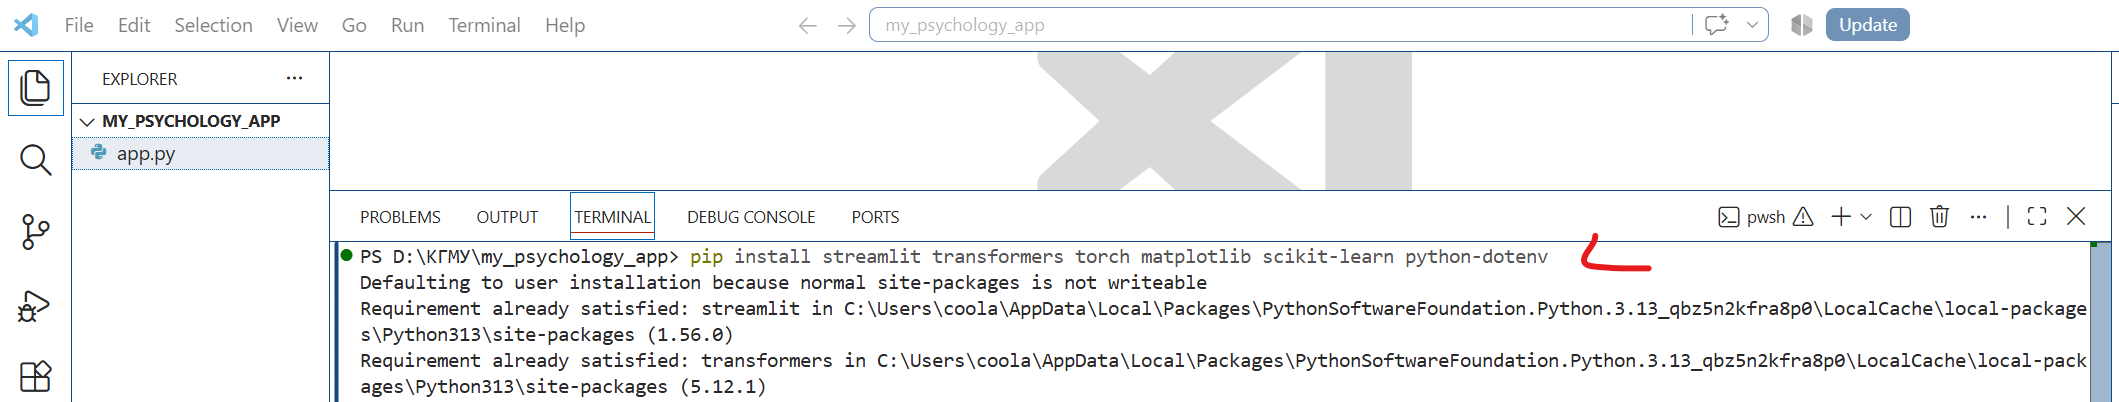

**2.6.3. Создание файла app.py**

1. В левой панели VS Code нажмите на иконку "New File" (создать файл) — это листок с плюсиком.
2. Назовите файл: `app.py` (обязательно с расширением `.py` — это означает Python-файл).
3. Нажмите Enter. Файл создан и открыт для редактирования.

**2.6.4. Первое приложение на Streamlit**

```python
import streamlit as st

st.title("🧠 Мой первый анализатор")
st.write("Привет, мир!")
name = st.text_input("Как вас зовут?")
if name:
    st.write(f"Привет, {name}!")
```


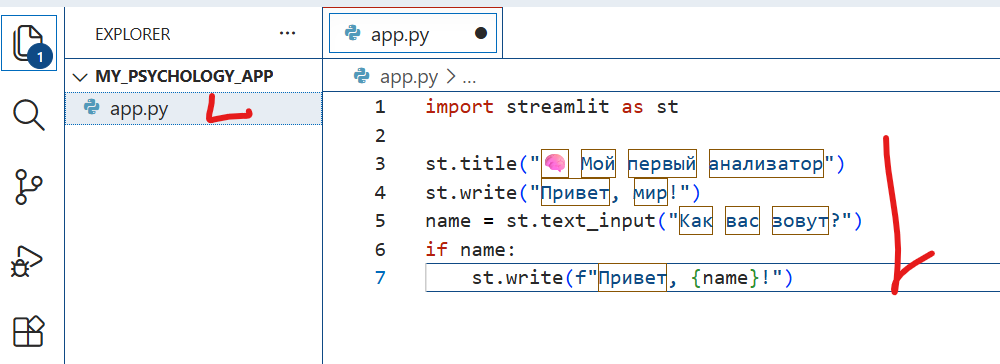


**2.6.5. Запуск приложения**

```bash
python -m streamlit run app.py
```

**Что должно произойти:**
- В браузере откроется страница `http://localhost:8501`.
- Вы увидите заголовок, текст и поле для ввода имени.

**Всего 5 строк — и у вас есть веб-приложение!**


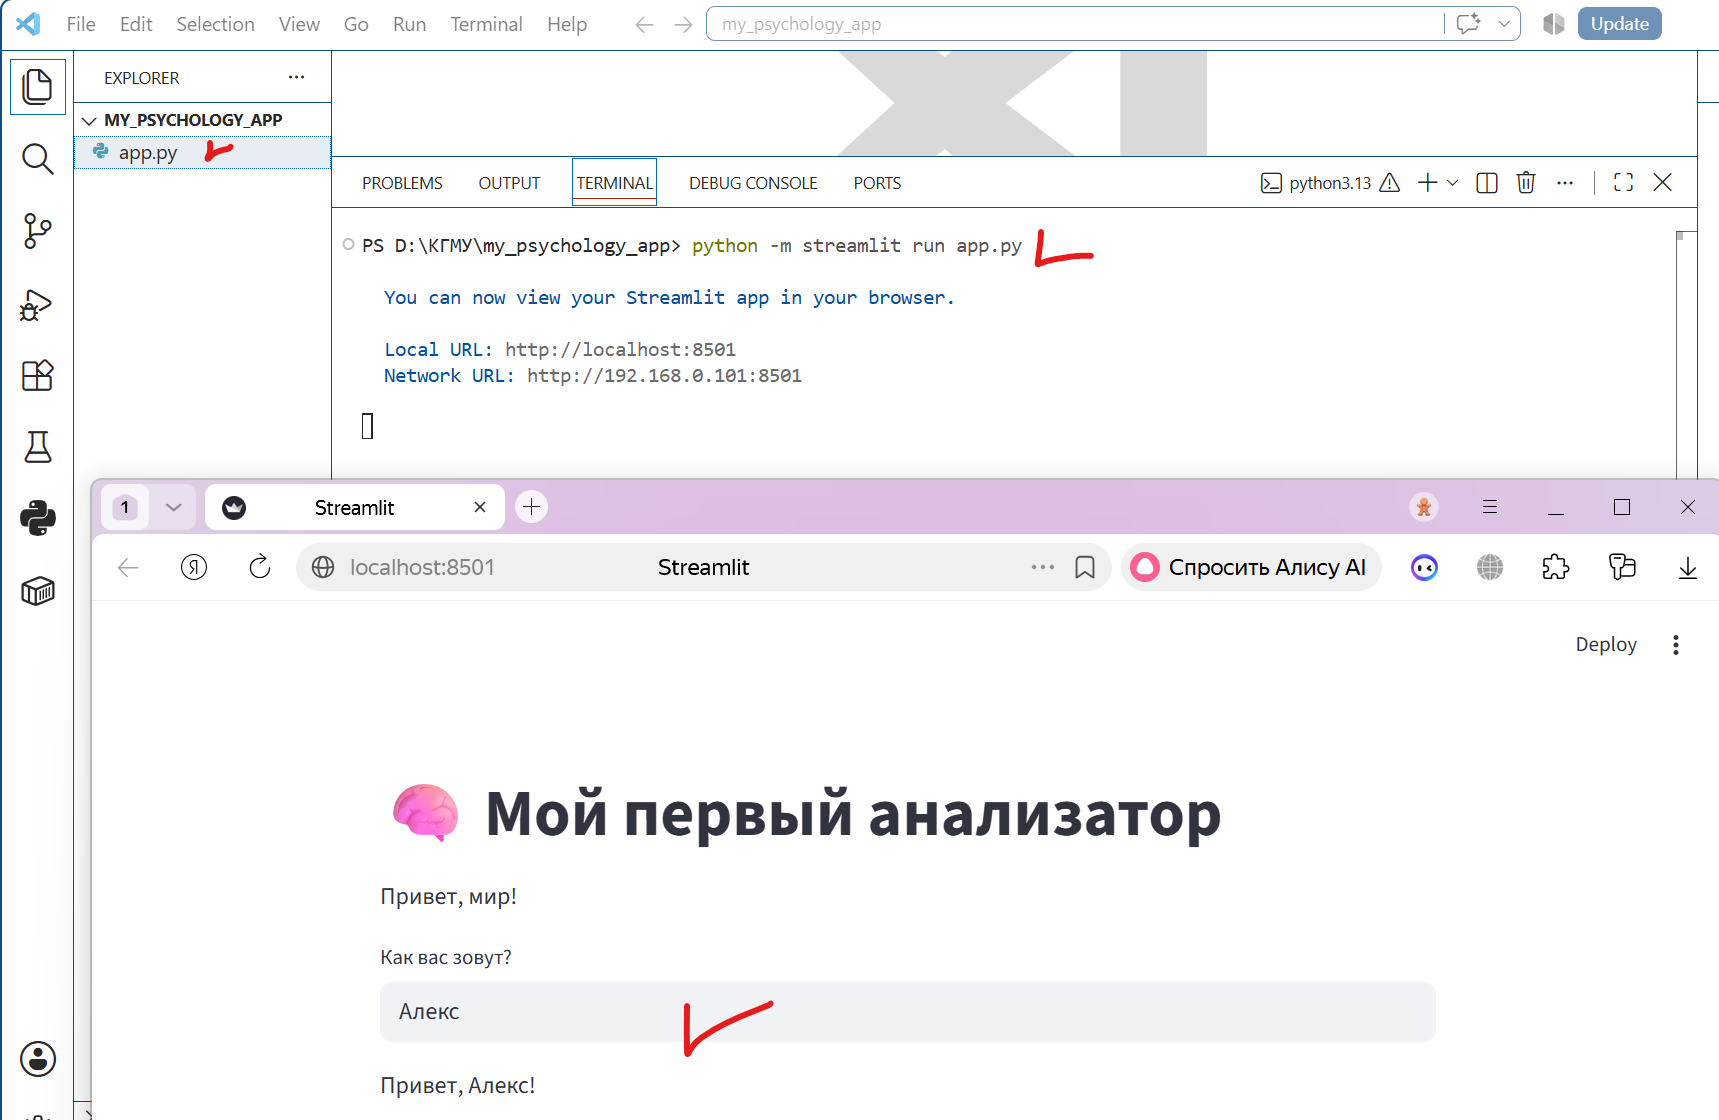


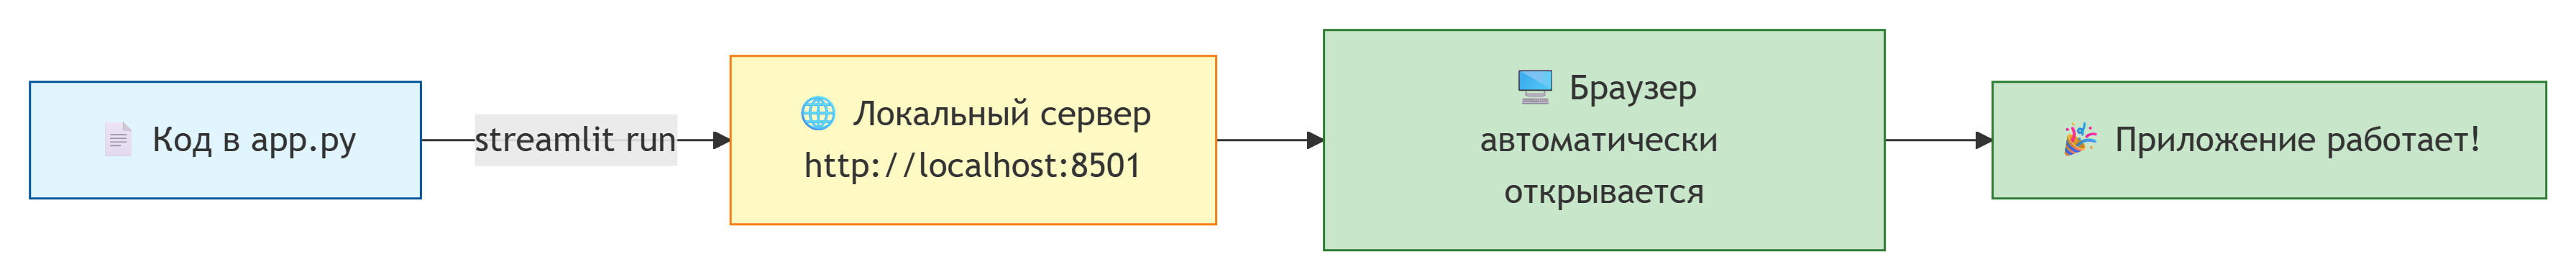



### 2.7. Gradio — альтернатива для быстрых демонстраций

**Что это:** библиотека, специализирующаяся на быстром создании интерфейсов для ML-моделей [2]. Она идеально подходит для демонстрации работы модели коллегам или заказчикам.

**Ключевые особенности:**

- **Максимальная простота** — буквально 3–5 строк кода для полноценного интерфейса.
- **Поддержка мультимедиа** — изображения, аудио, видео.
- **Интеграция с Hugging Face** — легко выложить на Spaces [3].
- **Интерактивные компоненты** — ползунки, кнопки, чекбоксы.
- **Автоматическое создание интерфейса** — Gradio сам определяет, какие элементы нужны.
- **Встроенные примеры** — можно добавить примеры текстов для быстрого тестирования.

**Интуитивная аналогия:**

> Gradio — это как **демонстрационный стенд** на конференции. Вы быстро раскладываете материалы, показываете примеры работы, и коллеги могут попробовать ваш инструмент за 5 минут.

**Почему Gradio подходит для быстрых демонстраций:**

| Причина | Объяснение |
|---------|------------|
| **Минимум кода** | 3–5 строк для полноценного интерфейса |
| **Встроенная интеграция с HF** | Легко подключить любую модель с Hugging Face |
| **Поддержка множества типов данных** | Текст, изображения, аудио, видео |
| **Быстрый деплой** | Hugging Face Spaces — бесплатно и просто |
| **Встроенные примеры** | Можно сразу показать работу на готовых текстах |

**Пример минимального приложения на Gradio:**

```python
import gradio as gr

def greet(name):
    return f"Привет, {name}!"

interface = gr.Interface(fn=greet, inputs="text", outputs="text")
interface.launch()
```

**Всего 6 строк — и у вас есть веб-приложение!**

**Более сложный пример: приложение для анализа тональности на Gradio**

```python
import gradio as gr
from transformers import pipeline

# Загружаем модель (загружается один раз)
model = pipeline("sentiment-analysis", model="blanchefort/rubert-base-cased-sentiment")

def analyze_sentiment(text):
    """Анализирует тональность текста"""
    result = model(text)[0]
    label = result['label']
    score = result['score']
    
    # Преобразуем метки в читаемый вид
    label_map = {"LABEL_0": "Негативный", "LABEL_1": "Нейтральный", "LABEL_2": "Позитивный"}
    label_ru = label_map.get(label, label)
    
    return f"{label_ru} (уверенность: {score*100:.1f}%)"

# Создаём интерфейс
interface = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(label="Введите текст для анализа:", lines=5),
    outputs=gr.Textbox(label="Результат анализа:"),
    title="🧠 Анализатор тональности текста",
    description="Введите текст на русском языке, и модель определит его тональность.",
    examples=[
        ["Сегодня был прекрасный день!"],
        ["Я чувствую себя ужасно..."],
        ["Результаты исследования показывают..."]
    ]
)

# Запускаем приложение
interface.launch()
```

---

### Запуск Gradio-приложения

#### Установка Gradio

Перед запуском убедитесь, что библиотека установлена:

```powershell
pip install gradio
```



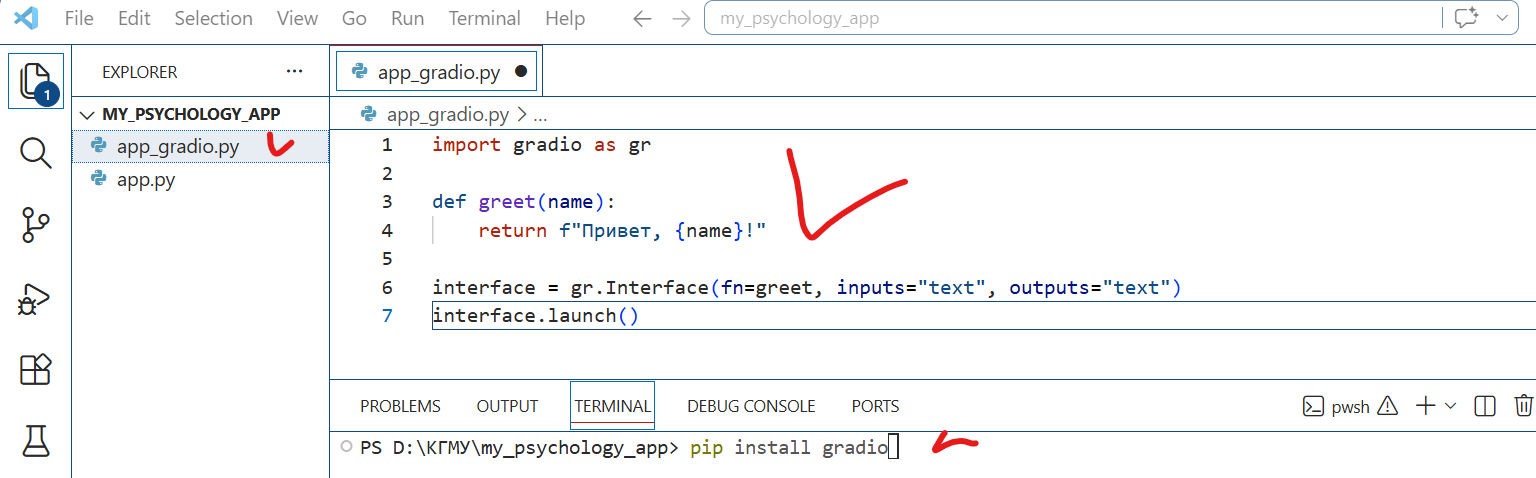


Если планируете использовать модели Hugging Face (как в примере выше), дополнительно установите:

```powershell
pip install transformers torch
```

#### Способы запуска

**Способ 1. Стандартный запуск через Python**

```powershell
python app_gradio.py
```



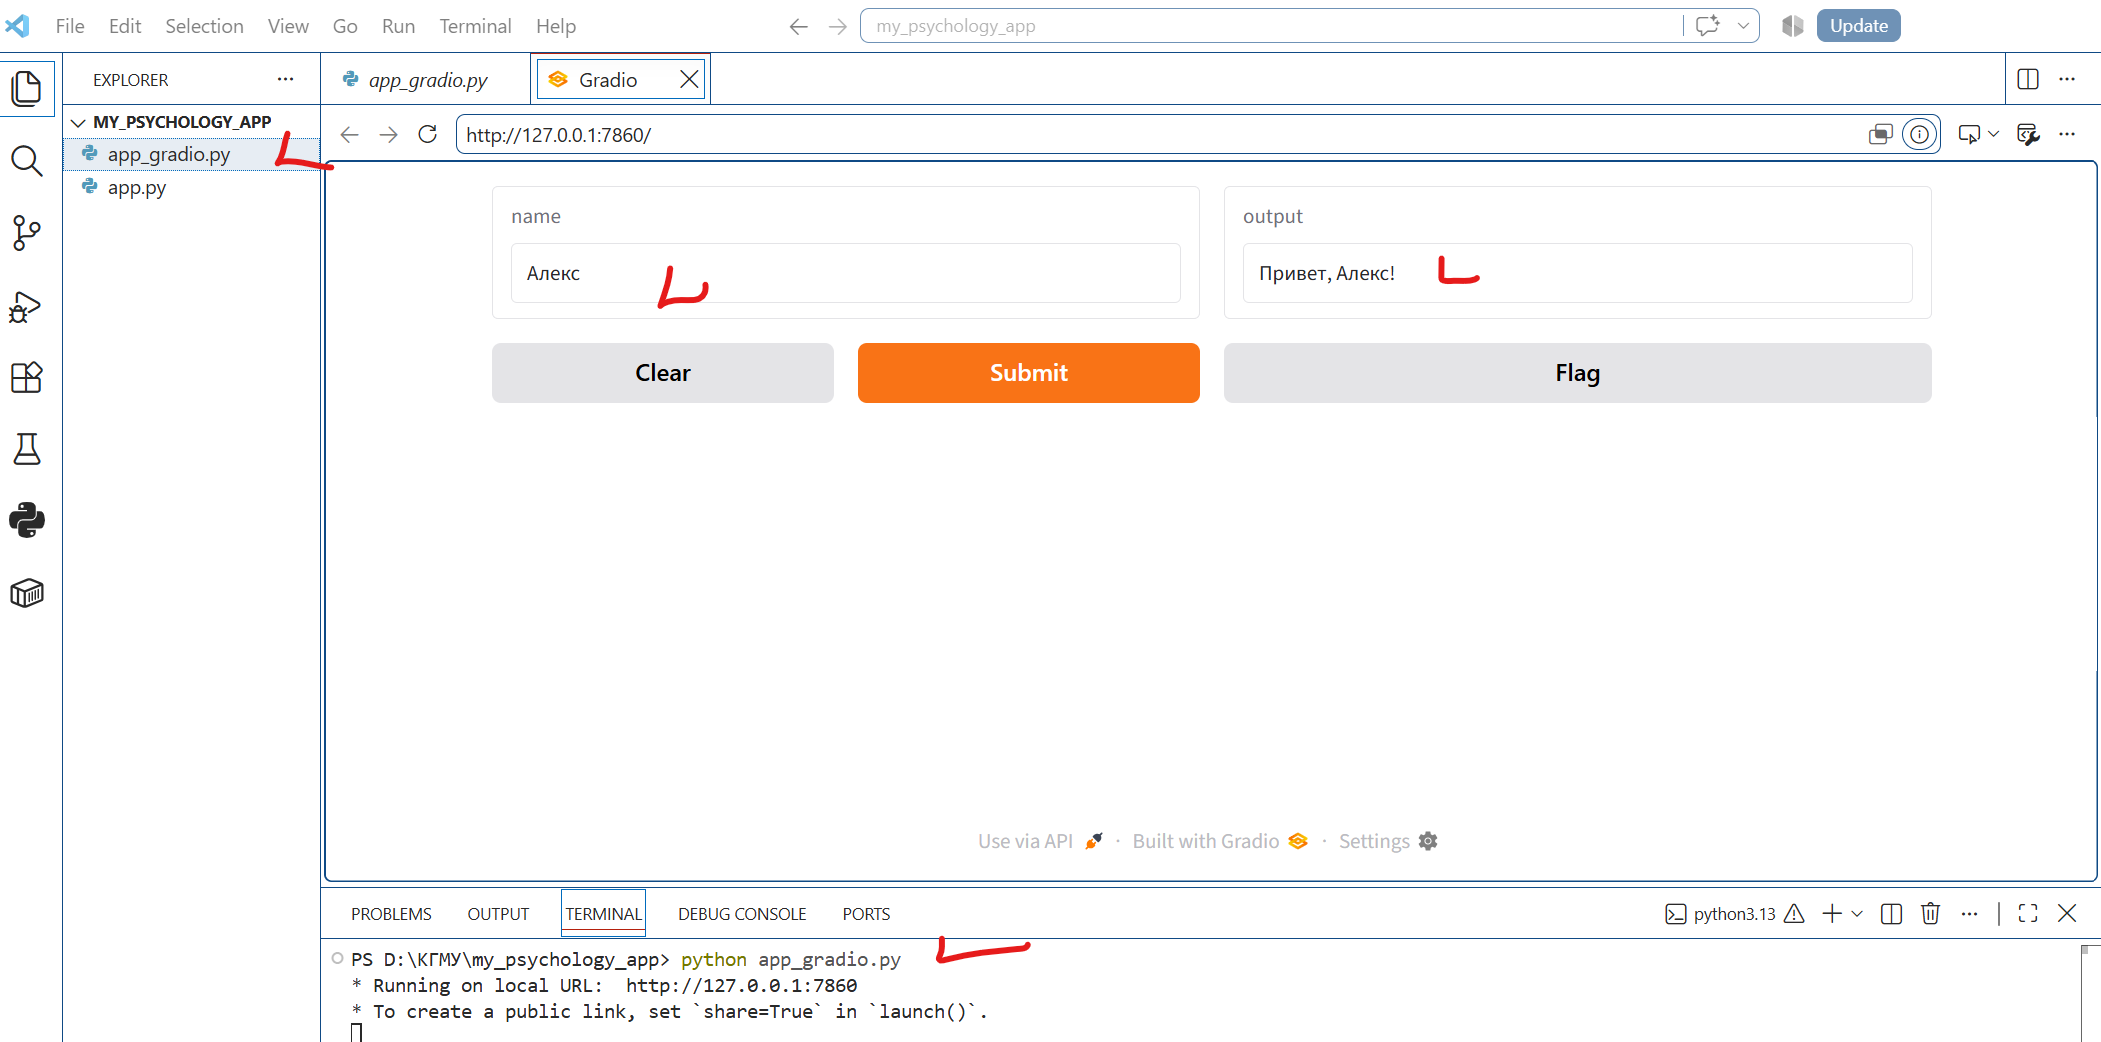


**Способ 2. Запуск через Python 3 (если есть несколько версий)**

```powershell
python3 app_gradio.py
```

**Способ 3. Запуск из VS Code**

- Откройте файл с кодом в VS Code
- Нажмите кнопку **"Run"** (▶️) в правом верхнем углу
- Или используйте сочетание клавиш `Ctrl + F5`

**Способ 4. Запуск с дополнительными параметрами**

```python
# Запуск с автоматическим открытием браузера (по умолчанию)
interface.launch()

# Запуск без открытия браузера
interface.launch(open_browser=False)

# Запуск на конкретном порту (по умолчанию 7860)
interface.launch(server_port=8080)

# Запуск с публичной ссылкой (доступно 72 часа)
interface.launch(share=True)

# Запуск в режиме отладки
interface.launch(debug=True)

# Комбинированный запуск
interface.launch(share=True, debug=True, server_port=8888)
```

#### Что вы увидите после запуска

После успешного запуска в терминале появится сообщение:

```
Running on local URL:  http://127.0.0.1:7860
Running on public URL: https://xxxxx.gradio.live (если указали share=True)

To create a public link, set `share=True` in `launch()`.
```

#### Особенности запуска Gradio

| Особенность | Описание |
|-------------|----------|
| **Автоматическое открытие браузера** | По умолчанию Gradio сам открывает браузер с приложением |
| **Публичная ссылка** | Параметр `share=True` создаёт временную публичную ссылку на 72 часа |
| **Горячая перезагрузка** | Поддерживается автоматическая перезагрузка при изменении кода |
| **Порт по умолчанию** | 7860 (можно изменить через `server_port`) |
| **Режим отладки** | `debug=True` показывает расширенную информацию об ошибках |

#### Названия файлов для VS Code

Рекомендуемые названия для файлов с Gradio-приложениями:

| Название файла | Рекомендация |
|----------------|--------------|
| **`gradio_app.py`** | ✅ Основной вариант — понятно и универсально |
| **`app_gradio.py`** | ✅ Хорошо, если в проекте несколько фреймворков |
| **`demo.py`** | ✅ Для быстрых демонстраций и прототипов |
| **`main.py`** | ⚠️ Если приложение основное (но лучше уточнить в названии) |
| **`sentiment_app.py`** | ✅ Для конкретного приложения (анализ тональности) |
| **`interface.py`** | ⚠️ Слишком общее название |
| **`app.py`** | ❌ Может конфликтовать со Streamlit-приложением |

**Рекомендация:** используйте `gradio_app.py` или `app_gradio.py`, чтобы избежать путаницы с файлами других фреймворков.

#### Структура проекта с несколькими фреймворками

```
my_psychology_app/
├── app.py                 # Streamlit-приложение
├── gradio_app.py          # Gradio-приложение ✅
├── requirements.txt       # Зависимости проекта
├── README.md             # Документация
├── .gitignore            # Игнорируемые файлы
├── models/               # Папка с моделями
│   └── sentiment_model.pth
├── utils/                # Вспомогательные функции
│   └── preprocess.py
└── data/                 # Данные для примеров
    └── sample_texts.txt
```

#### Сравнение запуска Streamlit и Gradio

| Характеристика | Streamlit | Gradio |
|----------------|-----------|--------|
| **Команда запуска** | `streamlit run app.py` или `python -m streamlit run app.py` | `python gradio_app.py` |
| **Порт по умолчанию** | 8501 | 7860 |
| **Авто-открытие браузера** | Да | Да |
| **Публичная ссылка** | Через сторонние сервисы | Встроенная (`share=True`) |
| **Горячая перезагрузка** | Да (по умолчанию) | Да (с параметром) |
| **Сложность запуска** | Требуется отдельная команда | Стандартный Python-скрипт |

#### Быстрый старт: пошаговая инструкция

```powershell
# 1. Установите необходимые библиотеки
pip install gradio transformers torch

# 2. Создайте файл gradio_app.py в VS Code
# (скопируйте код из примера выше)

# 3. Запустите приложение
python gradio_app.py

# 4. Откройте браузер по адресу: http://127.0.0.1:7860

# 5. Для публичного доступа добавьте share=True
# python gradio_app.py (после изменения кода)
```

#### Частые ошибки при запуске и их решение

| Ошибка | Решение |
|--------|---------|
| `ModuleNotFoundError: No module named 'gradio'` | Установите Gradio: `pip install gradio` |
| `Port 7860 is already in use` | Укажите другой порт: `interface.launch(server_port=8888)` |
| `CUDA out of memory` | Используйте CPU: `pipeline(..., device=-1)` |
| `Transformers not installed` | Установите: `pip install transformers torch` |
| Браузер не открывается автоматически | Добавьте `open_browser=False` и откройте вручную по ссылке |

#### Gradio vs Streamlit: когда что выбрать

| Критерий | Gradio | Streamlit |
|----------|--------|-----------|
| **Скорость создания** | ⭐⭐⭐⭐⭐ (3-5 строк) | ⭐⭐⭐⭐ (требует больше кода) |
| **ML-демонстрации** | ⭐⭐⭐⭐⭐ (идеально) | ⭐⭐⭐⭐ (хорошо) |
| **Дашборды и аналитика** | ⭐⭐ | ⭐⭐⭐⭐⭐ (идеально) |
| **Интерактивность** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Встроенные примеры** | ⭐⭐⭐⭐⭐ (из коробки) | ⭐⭐⭐ (нужно реализовывать) |
| **Деплой на HF Spaces** | ⭐⭐⭐⭐⭐ (нативная поддержка) | ⭐⭐⭐⭐ (поддерживается) |
| **Кастомизация дизайна** | ⭐⭐ | ⭐⭐⭐⭐ |

**Вывод:** Gradio лучше для быстрых ML-демонстраций и прототипов, а Streamlit — для полноценных веб-приложений с дашбордами и сложной логикой.

#### Рекомендация по использованию

Используйте Gradio, когда нужно:
- Быстро показать работу модели коллегам или заказчикам
- Создать интерактивный демо-стенд
- Выложить демо на Hugging Face Spaces
- Минимальный код и максимальная скорость

Используйте Streamlit, когда нужно:
- Создать полноценное веб-приложение
- Построить сложные дашборды с графиками
- Реализовать сложную логику навигации
- Интегрировать с базами данных и внешними API


---

### 2.8. Сравнение Streamlit и Gradio: подробная таблица

| Критерий | Streamlit | Gradio |
|----------|-----------|--------|
| **Лучшее применение** | Полноценные приложения, дашборды | Быстрые демонстрации моделей |
| **Гибкость интерфейса** | Высокая — можно создавать сложные макеты | Ограниченная — интерфейс определяется автоматически |
| **Сложность освоения** | Очень низкая | Очень низкая |
| **Для кого** | Для создания клинических инструментов | Для быстрого показа модели коллегам |
| **Облачный хостинг** | Streamlit Cloud | Hugging Face Spaces |
| **Количество кода** | 5–50 строк | 3–10 строк |
| **Поддержка вкладок** | ✅ Да (st.tabs) | ❌ Нет (только отдельные интерфейсы) |
| **Визуализация** | ✅ Встроенная (matplotlib, plotly) | ⚠️ Ограниченная |
| **Боковая панель** | ✅ Да (st.sidebar) | ❌ Нет |
| **Кеширование** | ✅ Да (@st.cache_resource) | ⚠️ Ограниченное |
| **Мультимедиа** | ⚠️ Ограниченная | ✅ Отличная (изображения, аудио, видео) |
| **Интеграция с Hugging Face** | ✅ Через transformers | ✅ Отличная (из коробки) |
| **Примеры данных** | ❌ Нет встроенных | ✅ Да (examples) |
| **Кастомизация внешнего вида** | ✅ Высокая (CSS, темы) | ⚠️ Ограниченная (только темы) |
| **Поддержка состояния** | ✅ Да (st.session_state) | ❌ Нет |

---

### 2.9. Визуализация: сравнение архитектур




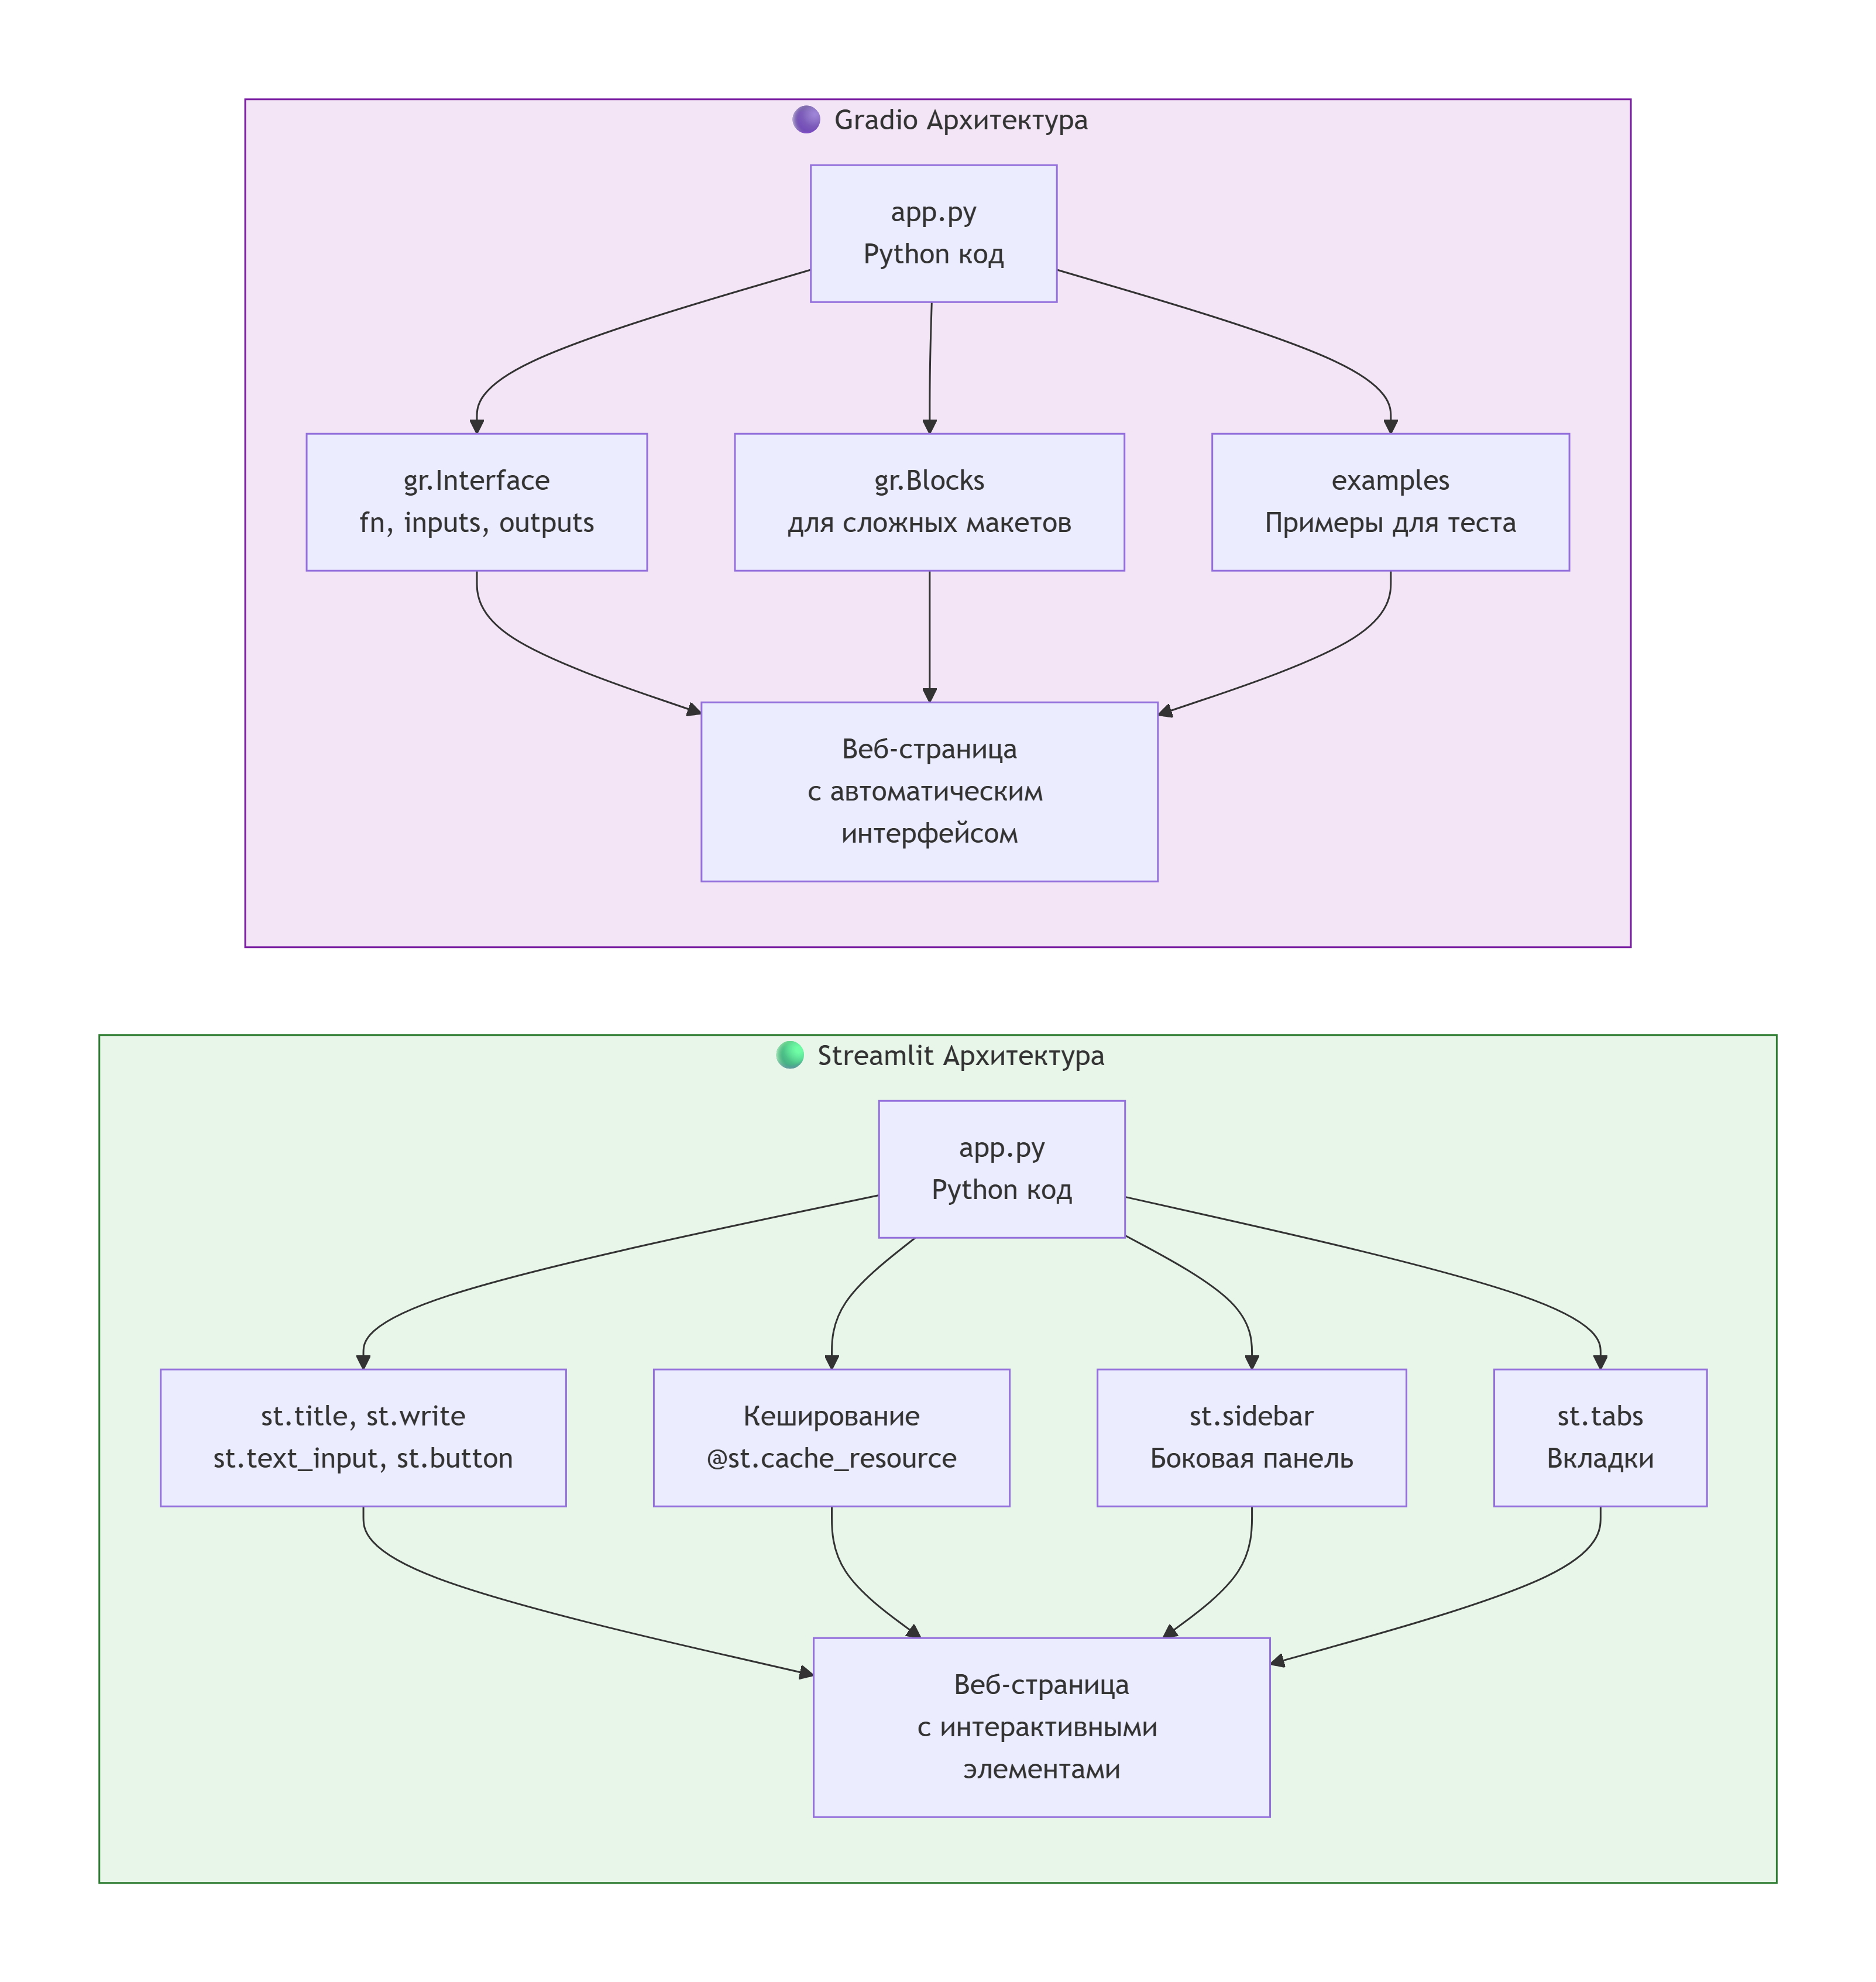



### 2.10. Когда выбирать Streamlit, а когда Gradio

| Ситуация | Выбор | Почему |
|----------|-------|--------|
| **Создание полноценного клинического инструмента** | **Streamlit** | Гибкость интерфейса, возможность создания сложных макетов |
| **Быстрый прототип для коллег** | **Gradio** | Минимум кода, быстрота разработки |
| **Приложение с графиками и таблицами** | **Streamlit** | Встроенная поддержка matplotlib, plotly, pandas |
| **Приложение с аудио/видео** | **Gradio** | Отличная поддержка мультимедиа |
| **Демонстрация модели на конференции** | **Gradio** | Быстрый запуск, красивые примеры |
| **Исследовательский проект** | **Streamlit** | Лучше для научных публикаций и отчётов |
| **Приложение для пациентов** | **Streamlit** | Профессиональный вид, кастомизация |
| **Интеграция с Hugging Face** | **Gradio** | Проще всего выложить на HF Spaces |
| **Приложение с настройками** | **Streamlit** | Боковая панель, ползунки, чекбоксы |
| **Быстрый тест модели** | **Gradio** | 3 строки кода, и готово |

**Практический совет для психологов:**

> Если вы хотите **показать модель коллегам** — используйте **Gradio** (3–5 строк кода, и готово).
>
> Если вы хотите **создать инструмент для практического использования** в клинике — используйте **Streamlit** (больше контроля над интерфейсом).
>
> Если вы хотите **опубликовать исследование** — используйте **Streamlit** (профессиональный вид, графики).

**Интуитивная аналогия:**

> - **Gradio** — это как **демонстрационный стенд** на выставке: быстро развернуть, легко показать, но не для постоянной работы.
> - **Streamlit** — это как **полноценный кабинет** психолога: всё продумано для длительной работы, есть все необходимые инструменты.

---

### 2.11. Практический чек-лист для выбора инструмента




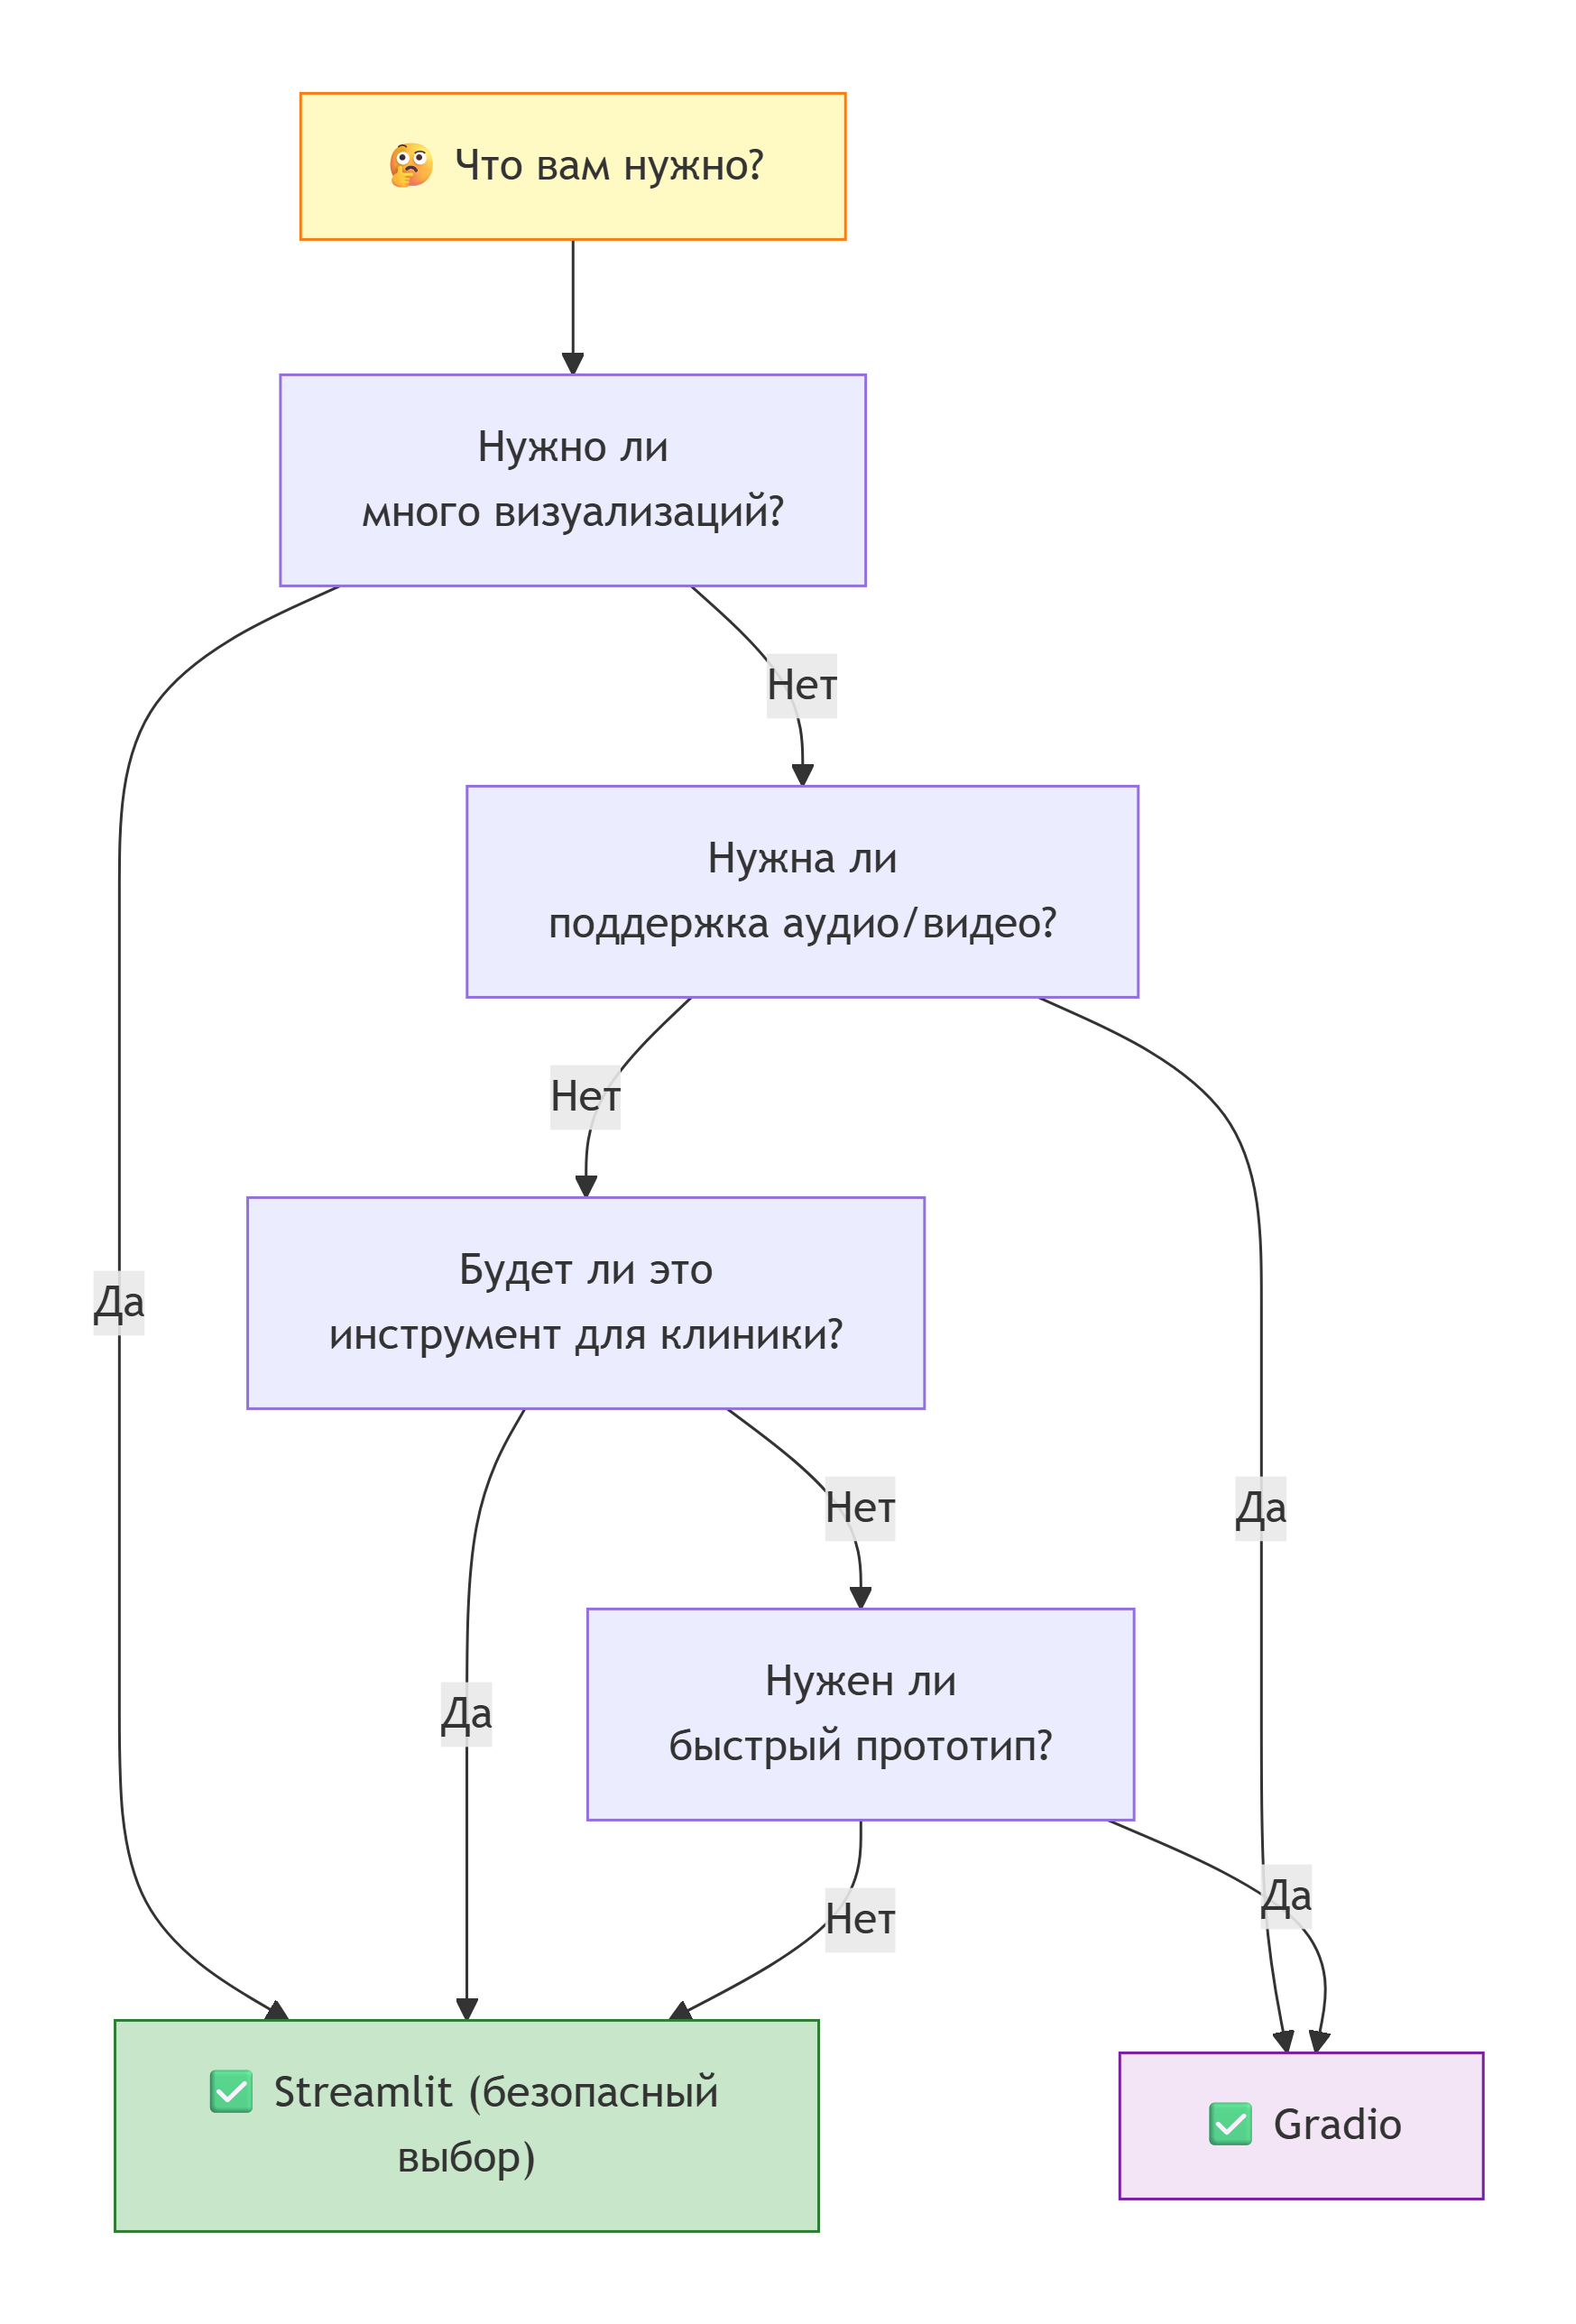



### 2.12. Итоговые рекомендации для психологов

| Если вы хотите... | Используйте | Почему |
|-------------------|-------------|--------|
| Быстро показать модель коллегам | **Gradio** | 3–5 строк кода, публичная ссылка за 5 минут |
| Создать инструмент для клиники | **Streamlit** | Больше контроля над интерфейсом |
| Опубликовать исследование с демонстрацией | **Gradio** | Легко выложить на Hugging Face Spaces |
| Создать дашборд для анализа данных | **Streamlit** | Встроенная визуализация и таблицы |
| Интегрировать аудио или видео | **Gradio** | Отличная поддержка мультимедиа |
| Работать с конфиденциальными данными | **Streamlit** (локально) | Полный контроль над данными |
| Создать приложение с настройками | **Streamlit** | Боковая панель, ползунки, чекбоксы |
| Протестировать новую модель | **Gradio** | Минимальный код, быстрый запуск |

---

### 2.13. Основные выводы раздела

1. **Для работы с кодом нужен редактор.** Мы используем **VS Code** — бесплатный, мощный и простой в освоении.

2. **Установка включает три шага:** установка VS Code, установка Python, установка расширения Python в VS Code.

3. **Проект начинается с папки.** Создайте папку, откройте её в VS Code, создайте файл `app.py`.

4. **Streamlit и Gradio** позволяют создавать веб-приложения без знания веб-разработки.

5. **Streamlit** лучше подходит для создания **полноценных клинических инструментов** — он даёт больше контроля над интерфейсом, поддерживает вкладки, боковые панели, кеширование.

6. **Gradio** лучше подходит для **быстрых демонстраций** — минимальный код, встроенные примеры, отличная поддержка мультимедиа.

7. **Выбор инструмента** зависит от задачи: для клиники → Streamlit, для презентации → Gradio.

8. **Оба инструмента** бесплатны, имеют облачный хостинг и поддерживают русский язык.

9. **Навык создания веб-приложений** становится важной компетенцией современного психолога-исследователя [5].


# 3. ПОШАГОВАЯ ИНСТРУКЦИЯ: СОЗДАНИЕ STREAMLIT-ПРОЕКТА

**Это центральный раздел лекции.** К концу этой части каждый студент сможет создать собственное веб-приложение. Мы пройдём все этапы — от установки до запуска.

---

### 3.0. Прежде чем начать: что нам понадобится

**Интуитивная аналогия:**

> Представьте, что вы собираетесь оборудовать кабинет для психологической практики. Вам нужно:
> - Помещение (компьютер).
> - Мебель (редактор кода).
> - Инструменты (библиотеки Python).
> - Документы (файлы проекта).

**Нам понадобится:**

| Что | Где взять | Зачем |
|-----|-----------|-------|
| **VS Code** | https://code.visualstudio.com/ | Редактор кода (место, где мы пишем программы) |
| **Python** | https://python.org/downloads/ | Язык программирования |
| **Streamlit** | `pip install streamlit` | Библиотека для веб-приложений |

**Если вы ещё не установили VS Code и Python:**

Вернитесь к разделу **2.3. Установка и настройка VS Code для работы с Python** — там есть подробная пошаговая инструкция.

**Если у вас нет VS Code, вы можете использовать альтернативы:**

| Редактор | Плюсы | Для кого |
|----------|-------|----------|
| **Блокнот** (Windows) | Есть на любом компьютере | Для самых простых файлов |
| **Sublime Text** | Лёгкий, красивый | Для быстрого редактирования |
| **PyCharm** | Отличная поддержка Python | Для профессиональной работы |

**Рекомендация:** всё же используйте **VS Code** — он бесплатный, мощный, и мы будем на него ориентироваться в инструкциях.

---

### 3.1. Шаг 1: Установка Streamlit

Для начала работы нужно установить библиотеку Streamlit. Это делается с помощью pip — менеджера пакетов Python.

**Что такое pip:** это программа, которая скачивает и устанавливает библиотеки из интернета.

**Интуитивная аналогия:**

> Представьте, что вы хотите скачать приложение на телефон. Вы идёте в App Store, находите приложение и устанавливаете. Pip — это App Store для Python-библиотек.

**Как открыть терминал в VS Code:**

1. Откройте VS Code.
2. Откройте папку вашего проекта (File → Open Folder).
3. Нажмите **Terminal** → **New Terminal** (или Ctrl + `).

**Установка Streamlit:**

```bash
# Установка Streamlit
pip install streamlit

# Проверка установки
streamlit --version
# Должно вывести что-то вроде: Streamlit, version 1.28.0
```

**Возможные проблемы и их решение:**

| Проблема | Причина | Решение |
|----------|---------|---------|
| `'pip' not found` | Python не установлен или не добавлен в PATH | Установите Python с официального сайта, отметьте "Add to PATH" |
| `Permission denied` | Недостаточно прав для установки | Используйте `pip install --user streamlit` |
| Версия устарела | Установлена старая версия | `pip install --upgrade streamlit` |
| `'streamlit' is not recognized` | Streamlit установлен, но не в PATH | Перезапустите терминал или VS Code |

---

### 3.2. Шаг 2: Создание проекта в VS Code

**Теперь создадим папку для проекта и откроем её в VS Code.**

**Способ 1: Через VS Code (рекомендуется для новичков)**

1. Откройте VS Code.
2. Нажмите **File** → **Open Folder** (или **Файл** → **Открыть папку**).
3. В открывшемся окне выберите место для проекта (например, диск D: или рабочий стол).
4. Нажмите **New Folder** (или правой кнопкой → Создать → Папку).
5. Назовите папку: `my_psychology_app`.
6. Нажмите **Select Folder** (или **Выбрать папку**).

**Способ 2: Через проводник Windows**

1. Откройте проводник (Win + E).
2. Перейдите на диск D: (или создайте папку на рабочем столе).
3. Нажмите правой кнопкой мыши → **Создать** → **Папка**.
4. Назовите папку: `my_psychology_app`.
5. Откройте VS Code.
6. Нажмите **File** → **Open Folder** и выберите созданную папку.

**Что должно появиться:** в левой панели VS Code (проводник) отобразится ваша папка. Пока она пустая.




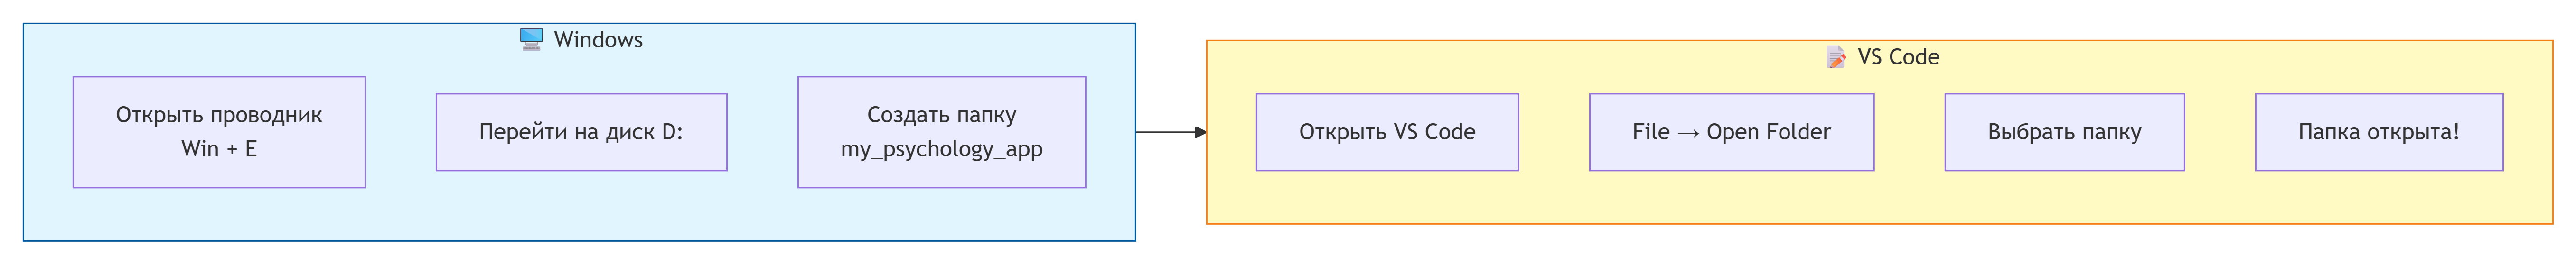



### 3.3. Шаг 3: Создание первого файла app.py

**Теперь создадим главный файл приложения.**

**Что такое `app.py`:** это главный входной файл, который Streamlit будет запускать. Обычно он находится в корне проекта.

**Как создать файл в VS Code:**

1. В левой панели (проводник) нажмите на иконку **"New File"** (создать файл) — это листок с плюсиком.
2. Назовите файл: `app.py` (обязательно с расширением `.py` — это означает Python-файл).
3. Нажмите Enter. Файл создан и открыт для редактирования.

**Альтернативный способ:** нажмите правой кнопкой мыши в проводнике → **New File** → назовите `app.py`.

**Что должно появиться:** в проводнике появился файл `app.py`, а в центре — пустая область для кода.

**Почему именно `app.py`?** Это стандартное имя для главного файла Streamlit-приложения. Streamlit ищет этот файл по умолчанию.

**Альтернативные названия:**
- `main.py` — тоже часто используется.
- `streamlit_app.py` — для деплоя на Streamlit Cloud.
- `app_psychology.py` — если у вас несколько приложений.

**Интуитивная аналогия:**

> `app.py` — это как главный кабинет психолога. Всё начинается здесь. Все остальные файлы — это как вспомогательные комнаты (архив, техника, комната ожидания).

---

### 3.4. Шаг 4: Первое приложение — "Hello, World!"

**Теперь напишем код и запустим его.**

```python
# app.py — первое приложение

import streamlit as st

# Заголовок страницы
st.title("🧠 Мой первый Streamlit-анализатор")

# Текст
st.write("Привет, мир Streamlit!")

# Интерактивный элемент
name = st.text_input("Как вас зовут?")
if name:
    st.write(f"Привет, {name}! Добро пожаловать в мир ИИ-инструментов для психологов.")
```

**Пояснение каждой строки:**

| Строка | Что делает |
|--------|------------|
| `import streamlit as st` | Импортируем библиотеку, сокращаем до `st` |
| `st.title("...")` | Создаёт большой заголовок на странице |
| `st.write("...")` | Выводит текст |
| `st.text_input("...")` | Создаёт поле для ввода текста |
| `if name:` | Проверяет, ввёл ли пользователь текст |
| `st.write(f"...")` | Выводит приветствие с именем пользователя |

**Запуск приложения:**

```bash
streamlit run app.py
```

**Что происходит:** Streamlit запускает локальный веб-сервер, и в браузере автоматически открывается страница с вашим приложением. Адрес по умолчанию: `http://localhost:8501`.





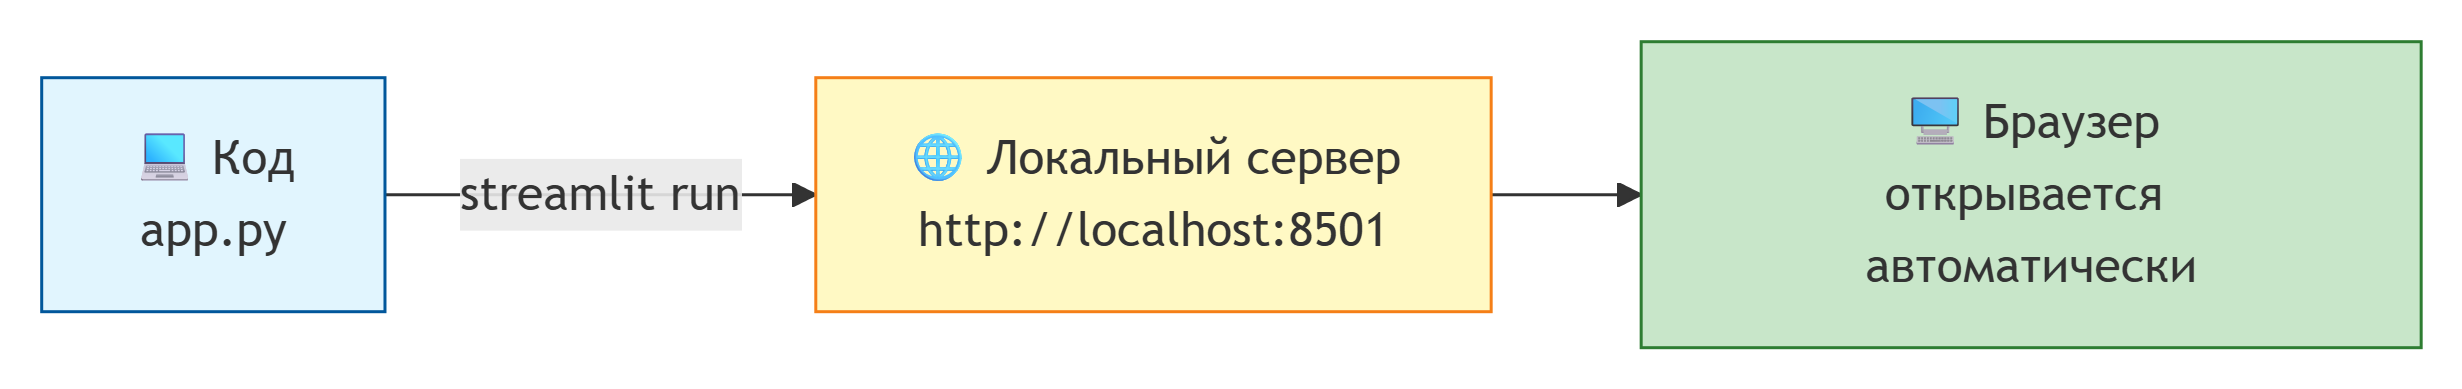

**Интуитивная аналогия:**

> Представьте, что вы создали опросник в Google Forms и нажали "Отправить". Google Forms создаёт ссылку, по которой можно открыть опросник. Streamlit делает то же самое — создаёт локальный сервер и показывает ваше приложение в браузере.

**Частые ошибки и их решение:**

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `FileNotFoundError: app.py` | Файл не найден | Проверьте, что вы в правильной папке и файл существует |
| `Address already in use` | Порт 8501 занят | Закройте другое приложение или используйте `streamlit run app.py --server.port 8502` |
| `ModuleNotFoundError: No module named 'streamlit'` | Streamlit не установлен | `pip install streamlit` |

---

### 3.5. Шаг 5: Структура проекта

Для серьёзного проекта нужна правильная организация файлов. Это поможет вам не запутаться в коде, когда проект вырастет.

**Интуитивная аналогия:**

> Это как структура кабинета психолога: главный кабинет (app.py), вспомогательные инструменты (utils), архив с тестами (models), документация (README). Всё на своих местах.

Вот минимальная структура:

```
my_psychology_app/           # папка проекта
│
├── app.py                   # главный файл приложения
├── requirements.txt         # список зависимостей
├── .env                     # переменные окружения (токены, пароли)
├── utils/                   # вспомогательный код
│   └── model_loader.py      # загрузка модели
│   └── helpers.py           # вспомогательные функции
├── models/                  # папка с моделями
│   └── best_model/          # ваша обученная модель из Практики 6
├── data/                    # примеры данных
│   └── sample_texts.txt
└── README.md                # описание проекта
```

**Что куда класть:**

| Папка/файл | Что там должно быть |
|------------|---------------------|
| `app.py` | Главный код приложения, интерфейс |
| `utils/` | Вспомогательные функции (загрузка модели, обработка текста) |
| `models/` | Обученные модели (не код, а файлы весов) |
| `data/` | Тестовые данные, примеры |
| `requirements.txt` | Список всех библиотек с версиями |
| `.env` | Секретные данные (не загружать в GitHub!) |
| `README.md` | Описание проекта, инструкция по запуску |

**Создание структуры в VS Code:**

1. В левой панели нажмите на иконку **"New Folder"** (создать папку).
2. Назовите: `utils`, нажмите Enter.
3. Снова нажмите "New Folder" → название: `models`.
4. Снова → название: `data`.
5. Создайте файлы в корне: `requirements.txt`, `README.md`, `.env`.

**Через терминал:**

```bash
# Для Windows (CMD или PowerShell):
mkdir utils models data
type nul > requirements.txt
type nul > README.md
type nul > .env

# Для Mac/Linux:
mkdir utils models data
touch requirements.txt README.md .env
```

---

### 3.6. Шаг 6: Ключевые компоненты Streamlit

Прежде чем писать полноценное приложение, познакомимся с основными компонентами, которые мы будем использовать.

#### 3.6.1. Компоненты для ввода данных

| Компонент | Пример кода | Что делает |
|-----------|-------------|------------|
| **Текстовое поле** | `st.text_area("Введите текст:")` | Большое поле для ввода текста |
| **Строка ввода** | `st.text_input("Имя:")` | Короткое поле для одной строки |
| **Кнопка** | `st.button("Анализировать")` | Кнопка для запуска действия |
| **Ползунок** | `st.slider("Порог:", 0.0, 1.0, 0.5)` | Выбор значения в диапазоне |
| **Загрузка файла** | `st.file_uploader("Загрузите файл")` | Загрузка файлов с компьютера |
| **Выбор из списка** | `st.selectbox("Выберите:", ["A", "B", "C"])` | Выпадающий список |

#### 3.6.2. Компоненты для вывода данных

| Компонент | Пример кода | Что делает |
|-----------|-------------|------------|
| **Текст** | `st.write("Результат:")` | Вывод текста |
| **Успех** | `st.success("Готово!")` | Зелёное сообщение об успехе |
| **Предупреждение** | `st.warning("Проверьте ввод")` | Жёлтое предупреждение |
| **Ошибка** | `st.error("Ошибка!")` | Красное сообщение об ошибке |
| **Прогресс-бар** | `st.progress(0.75)` | Полоска прогресса |
| **График** | `st.pyplot(fig)` | Вывод графика matplotlib |
| **Таблица** | `st.dataframe(df)` | Интерактивная таблица |
| **Вкладки** | `st.tabs(["Вкладка 1", "Вкладка 2"])` | Переключаемые вкладки |

#### 3.6.3. Кеширование

**Что это:** механизм, который запоминает результат тяжёлых вычислений. Модель загружается один раз, а не при каждом взаимодействии.

```python
@st.cache_resource
def load_model():
    """Загружает модель один раз и сохраняет в кэше"""
    return heavy_model_loading_function()
```

**Интуитивная аналогия:**

> Представьте, что вы загружаете в кабинет тяжёлую базу данных на флешке. Вместо того чтобы вставлять флешку каждый раз, когда вам нужна информация, вы оставляете её в компьютере. `@st.cache_resource` — это как «оставить флешку в компьютере»: модель загружается один раз и остаётся в памяти.

**Почему это важно:**

- Без кеширования модель будет загружаться при каждом нажатии кнопки (медленно!)
- С кешированием модель загружается один раз при запуске приложения

---

### 3.7. Шаг 7: Полный код приложения

Теперь соберём все компоненты вместе и создадим полноценное приложение для анализа эмоций.

**Важное пояснение:** этот код предполагает, что у вас есть обученная модель из Практики 6 в папке `./models/best_model`. Если модели пока нет, вы можете использовать готовую модель из интернета (например, `blanchefort/rubert-base-cased-sentiment`).

**Где взять модель из Практики 6:**

1. После выполнения Практики 6 у вас появилась папка `./results` или `./best_model`.
2. Скопируйте эту папку в папку `models` вашего проекта.
3. Убедитесь, что в папке есть файлы: `config.json`, `pytorch_model.bin` (или `model.safetensors`), `tokenizer_config.json`, `vocab.txt`.

```python
# app.py — полноценное приложение для анализа эмоций

import streamlit as st
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline

# === НАСТРОЙКА СТРАНИЦЫ ===
# st.set_page_config задаёт имя страницы, иконку и макет
st.set_page_config(
    page_title="Анализатор эмоций",
    page_icon="🧠",
    layout="centered"
)

# === ЗАГОЛОВОК ===
st.title("🧠 Анализатор эмоций в тексте")
st.markdown("Введите текст, и модель определит эмоцию.")

# === ЗАГРУЗКА МОДЕЛИ (кэшируется) ===
@st.cache_resource
def get_model():
    """Загружает модель для классификации эмоций один раз"""
    # Путь к вашей модели из Практики 6
    # Если модели нет, используйте стандартную
    try:
        return pipeline(
            "text-classification",
            model="./models/best_model",  # путь к обученной модели
            device=-1  # -1 для CPU
        )
    except:
        return pipeline(
            "sentiment-analysis",
            model="blanchefort/rubert-base-cased-sentiment"
        )

model = get_model()

# === БОКОВАЯ ПАНЕЛЬ ===
with st.sidebar:
    st.header("⚙️ Настройки")
    
    # Ползунок для порога уверенности
    threshold = st.slider(
        "Порог уверенности:",
        min_value=0.0,
        max_value=1.0,
        value=0.5,
        step=0.05,
        help="Результат показывается, если уверенность модели выше порога"
    )
    
    # Информация о модели
    st.info("📊 Модель обучена на 10 000 текстах.\n\nКлассы: гнев, страх, радость, грусть.")
    
    # Кнопка сброса
    if st.button("🔄 Сбросить"):
        st.rerun()

# === ОСНОВНАЯ ЧАСТЬ ===
# Создаём две вкладки
tab1, tab2 = st.tabs(["📝 Ввод текста", "📁 Загрузка файла"])

# === ВКЛАДКА 1: Ввод текста ===
with tab1:
    # Поле для ввода текста
    user_text = st.text_area(
        "Введите текст для анализа:",
        placeholder="Например: Я сегодня чувствую себя ужасно, ничего не хочется делать...",
        height=150,
        help="Введите текст на русском или английском языке"
    )
    
    # Кнопка для запуска анализа
    if st.button("🔍 Анализировать", type="primary"):
        if user_text.strip():
            # Показываем спиннер во время обработки
            with st.spinner("⏳ Анализируем текст..."):
                # Вызов модели
                result = model(user_text)[0]
                emotion = result['label']
                confidence = result['score']
            
            # Проверка порога
            if confidence >= threshold:
                # Успешный результат
                st.success(f"**Определённая эмоция:** {emotion.upper()}")
                
                # Прогресс-бар
                st.progress(confidence)
                st.caption(f"Уверенность модели: {confidence*100:.1f}%")
                
                # График распределения вероятностей
                # В реальной модели здесь будут реальные вероятности
                # Для демонстрации используем пример
                emotions = ["гнев", "страх", "радость", "грусть"]
                # В реальном приложении замените на реальные вероятности
                probs = np.random.dirichlet(np.ones(4))
                
                fig, ax = plt.subplots(figsize=(8, 4))
                colors = ['#ff6b6b', '#ffd93d', '#6bcf7f', '#4dabf7']
                ax.bar(emotions, probs, color=colors)
                ax.set_ylim(0, 1)
                ax.set_ylabel("Вероятность")
                ax.set_title("Распределение эмоций")
                ax.grid(True, alpha=0.3, axis='y')
                st.pyplot(fig)
            else:
                # Уверенность ниже порога
                st.warning(
                    f"Уверенность модели ({confidence*100:.1f}%) "
                    f"ниже порога ({threshold*100:.1f}%). "
                    "Попробуйте другой текст."
                )
        else:
            st.warning("Пожалуйста, введите текст для анализа.")

# === ВКЛАДКА 2: Загрузка файла ===
with tab2:
    uploaded_file = st.file_uploader(
        "Загрузите текстовый файл (.txt):",
        type=["txt"],
        help="Загрузите текстовый файл для анализа"
    )
    
    if uploaded_file is not None:
        # Читаем содержимое файла
        content = uploaded_file.read().decode("utf-8")
        st.text_area("Содержимое файла:", content, height=200)
        
        # Кнопка для анализа файла
        if st.button("🔍 Анализировать файл"):
            st.info("✅ Анализ файла запущен...")
            # Здесь должен быть код, аналогичный анализу текста

# === ПОДВАЛ ===
st.divider()
st.caption(
    "⚠️ **Важное предупреждение:** Это демонстрационный инструмент, "
    "не медицинская диагностика. Результаты не являются диагнозом "
    "и не заменяют консультацию специалиста."
)
st.caption("🔒 Ваши данные не сохраняются на сервере.")
```

**Пояснение ключевых частей кода:**

| Часть кода | Что делает | Почему это важно |
|------------|------------|------------------|
| `st.set_page_config()` | Настройка внешнего вида страницы | Приложение выглядит профессионально |
| `@st.cache_resource` | Кеширование модели | Модель загружается один раз, а не при каждом клике |
| `st.sidebar` | Боковая панель | Для настроек и дополнительной информации |
| `st.tabs()` | Вкладки | Для организации интерфейса |
| `st.spinner()` | Индикатор загрузки | Пользователь видит, что происходит обработка |
| `st.progress()` | Прогресс-бар | Визуализация уверенности модели |

---

### 3.8. Шаг 8: Модуль загрузки модели

Вынесем загрузку модели в отдельный файл для чистоты кода.

```python
# utils/model_loader.py — загрузка модели

from transformers import pipeline

def load_model():
    """
    Загружает модель для классификации эмоций.
    Возвращает pipeline для инференса.
    
    Путь к модели: ./models/best_model
    Если модель не найдена, использует стандартную.
    """
    try:
        return pipeline(
            "text-classification",
            model="./models/best_model",  # путь к вашей обученной модели
            device=-1  # -1 для CPU, 0 для GPU (если есть)
        )
    except Exception as e:
        print(f"Ошибка загрузки модели: {e}")
        # Запасной вариант: используем стандартную модель
        return pipeline(
            "sentiment-analysis",
            model="blanchefort/rubert-base-cased-sentiment"
        )
```

**Пояснение:**

| Элемент | Что делает |
|---------|------------|
| `pipeline()` | Создаёт готовый пайплайн для инференса |
| `text-classification` | Тип задачи (классификация текста) |
| `model="./models/best_model"` | Путь к вашей модели |
| `device=-1` | Использовать CPU (не GPU) |

---

### 3.9. Шаг 9: Файл requirements.txt

Файл `requirements.txt` перечисляет все библиотеки, необходимые для работы приложения. Streamlit Cloud прочитает этот файл и установит всё автоматически.

```txt
streamlit==1.28.0
transformers==4.36.0
torch==2.1.0
matplotlib==3.7.0
numpy==1.24.0
scikit-learn==1.3.0
python-dotenv==1.0.0
```

**Почему нужны версии:**

| Без версий | С версиями |
|------------|------------|
| `streamlit` | `streamlit==1.28.0` |
| Установится последняя версия | Установится конкретная версия |
| Может быть несовместимость | Гарантированная совместимость |
| Трудно воспроизвести | Легко воспроизвести |

**Создание файла:**

```bash
# Через терминал:
echo "streamlit==1.28.0" > requirements.txt
echo "transformers==4.36.0" >> requirements.txt
# ... и так далее

# Или через VS Code: правой кнопкой → New File → requirements.txt
```

---

### 3.10. Шаг 10: Запуск и тестирование

```bash
# Запуск локально
streamlit run app.py

# Приложение открывается в браузере по адресу:
# http://localhost:8501
```

**Что проверять:**

| Что проверять | Как проверить | Ожидаемый результат |
|---------------|---------------|---------------------|
| Загрузка страницы | Открыть `http://localhost:8501` | Видим заголовок и поле ввода |
| Ввод текста | Написать текст, нажать кнопку | Получаем результат анализа |
| Загрузка файла | Загрузить .txt файл | Видим содержимое файла |
| Изменение порога | Сдвинуть ползунок | Результат появляется/исчезает |
| Обновление страницы | Обновить браузер | Страница загружается быстро (кеш) |

---

### 3.11. Схема: структура Streamlit-приложения




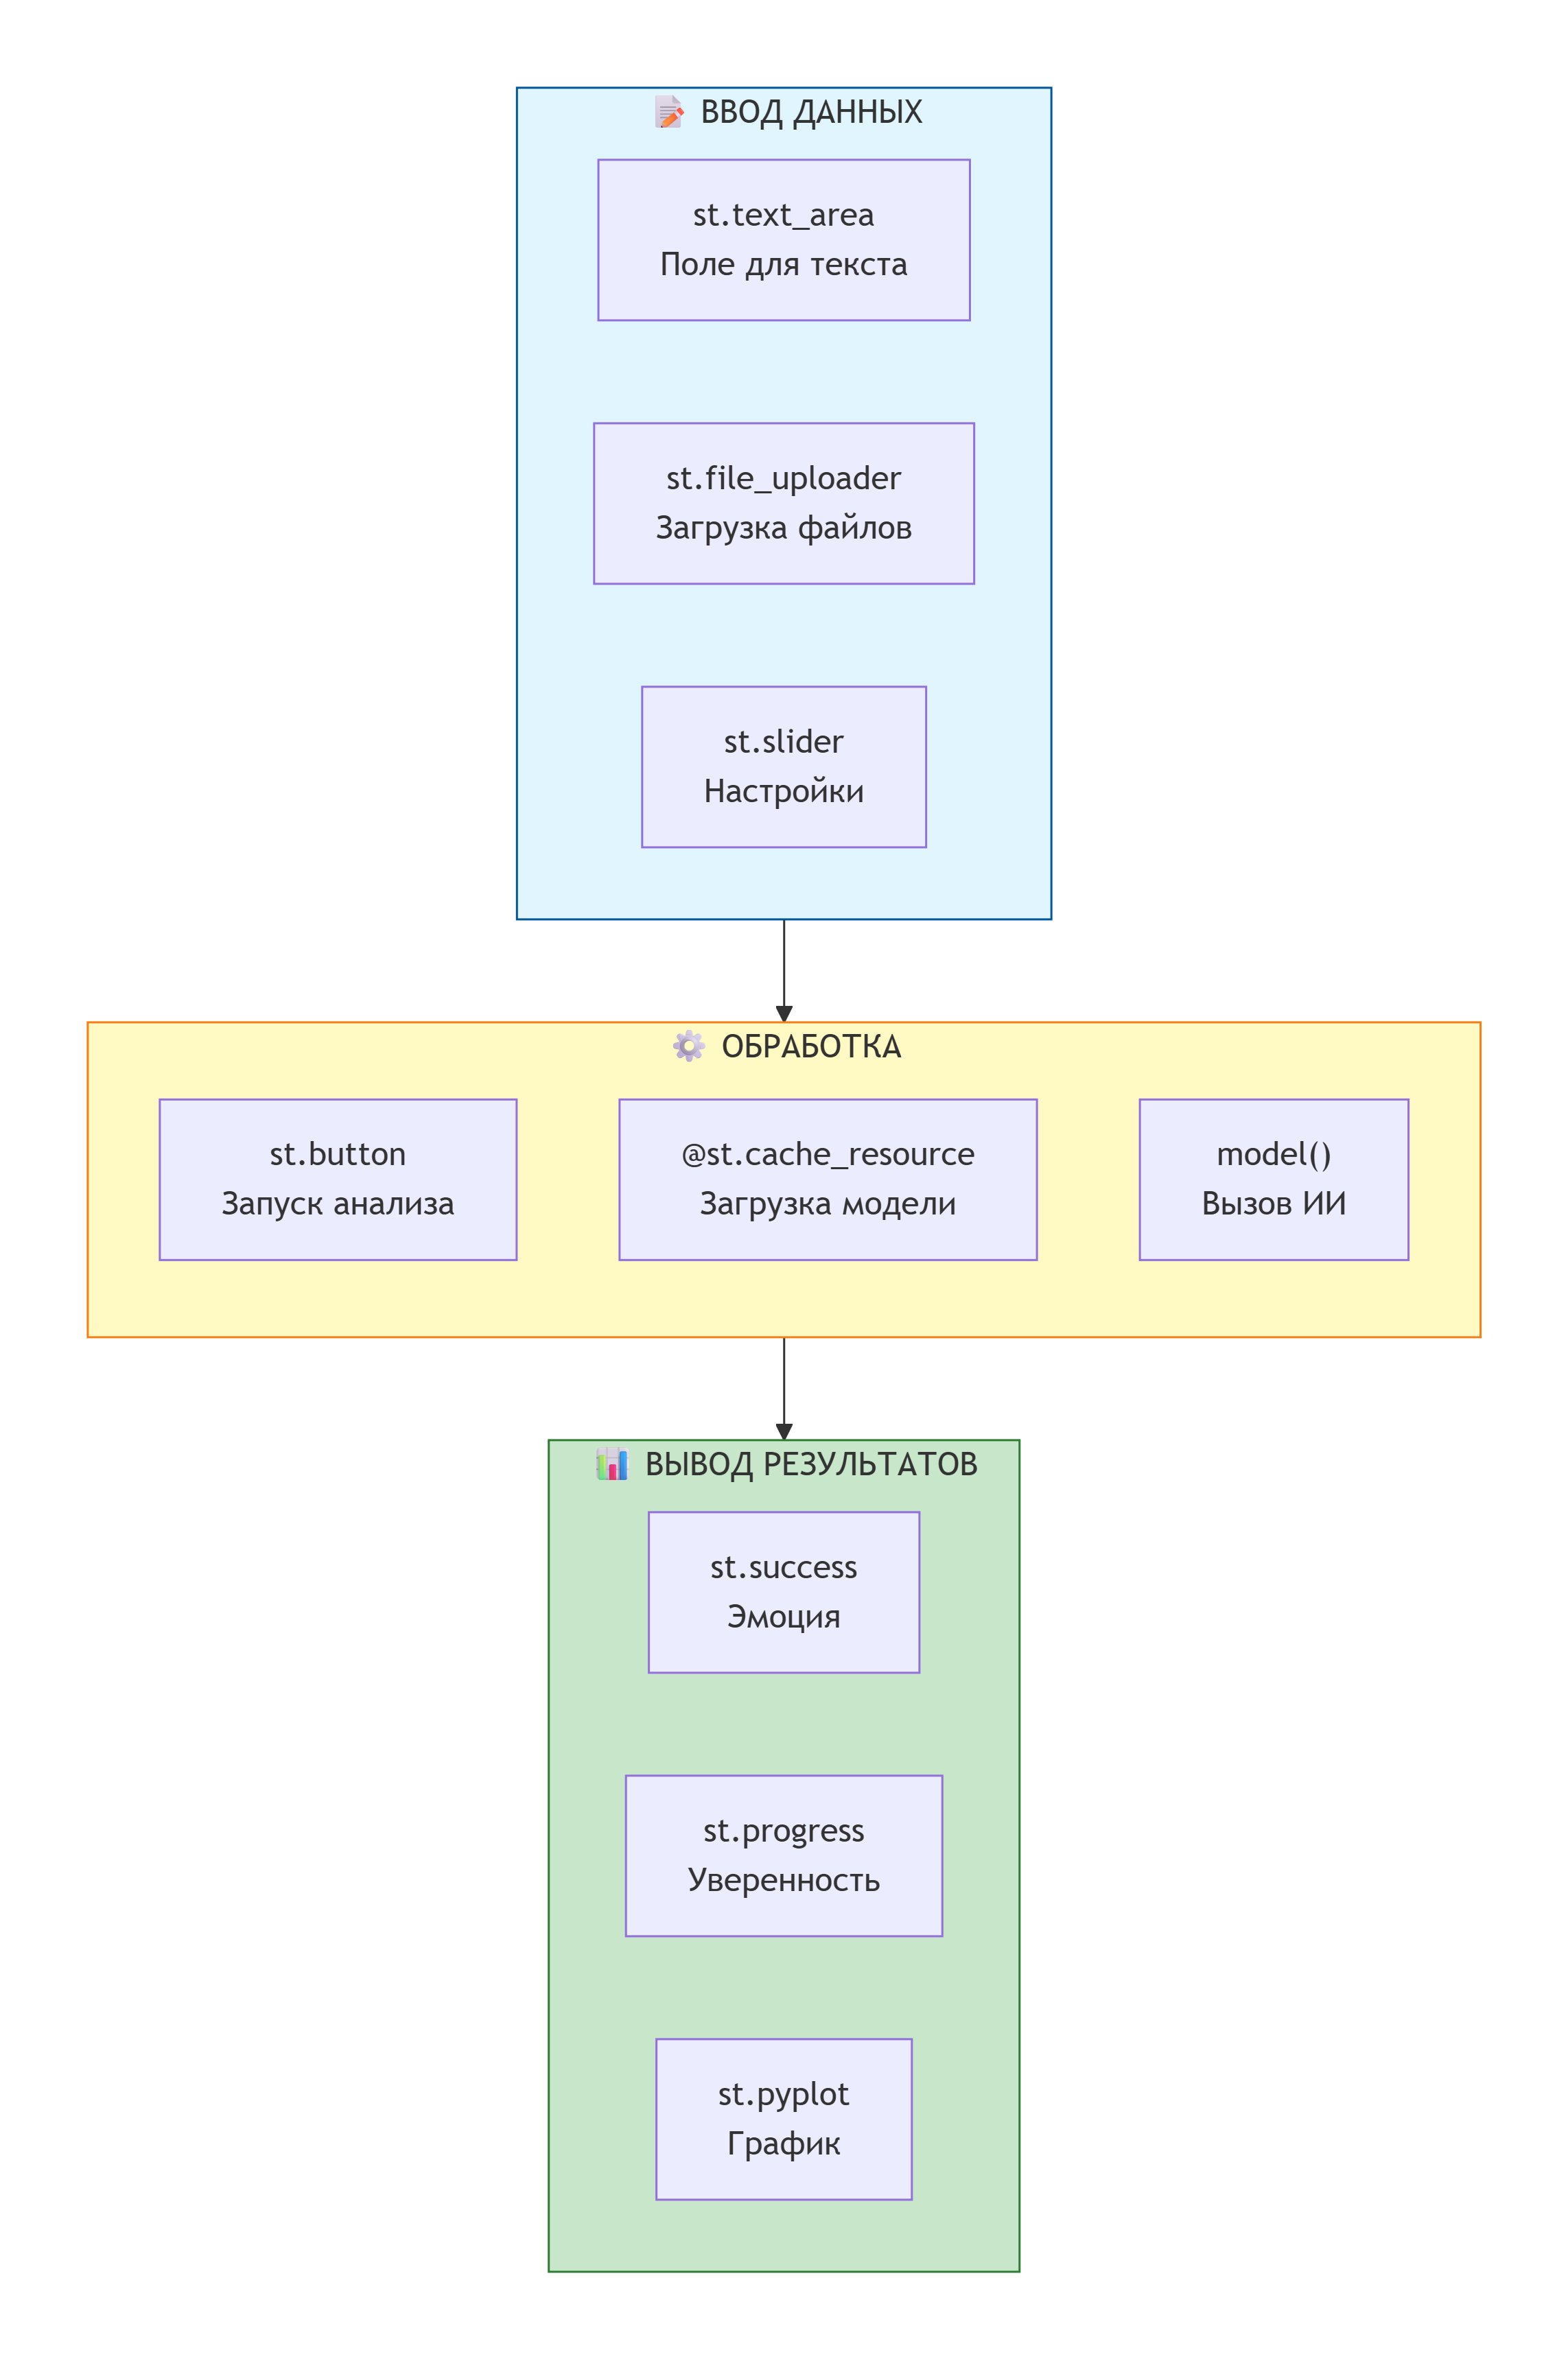



### 3.12. Схема: поток данных в приложении



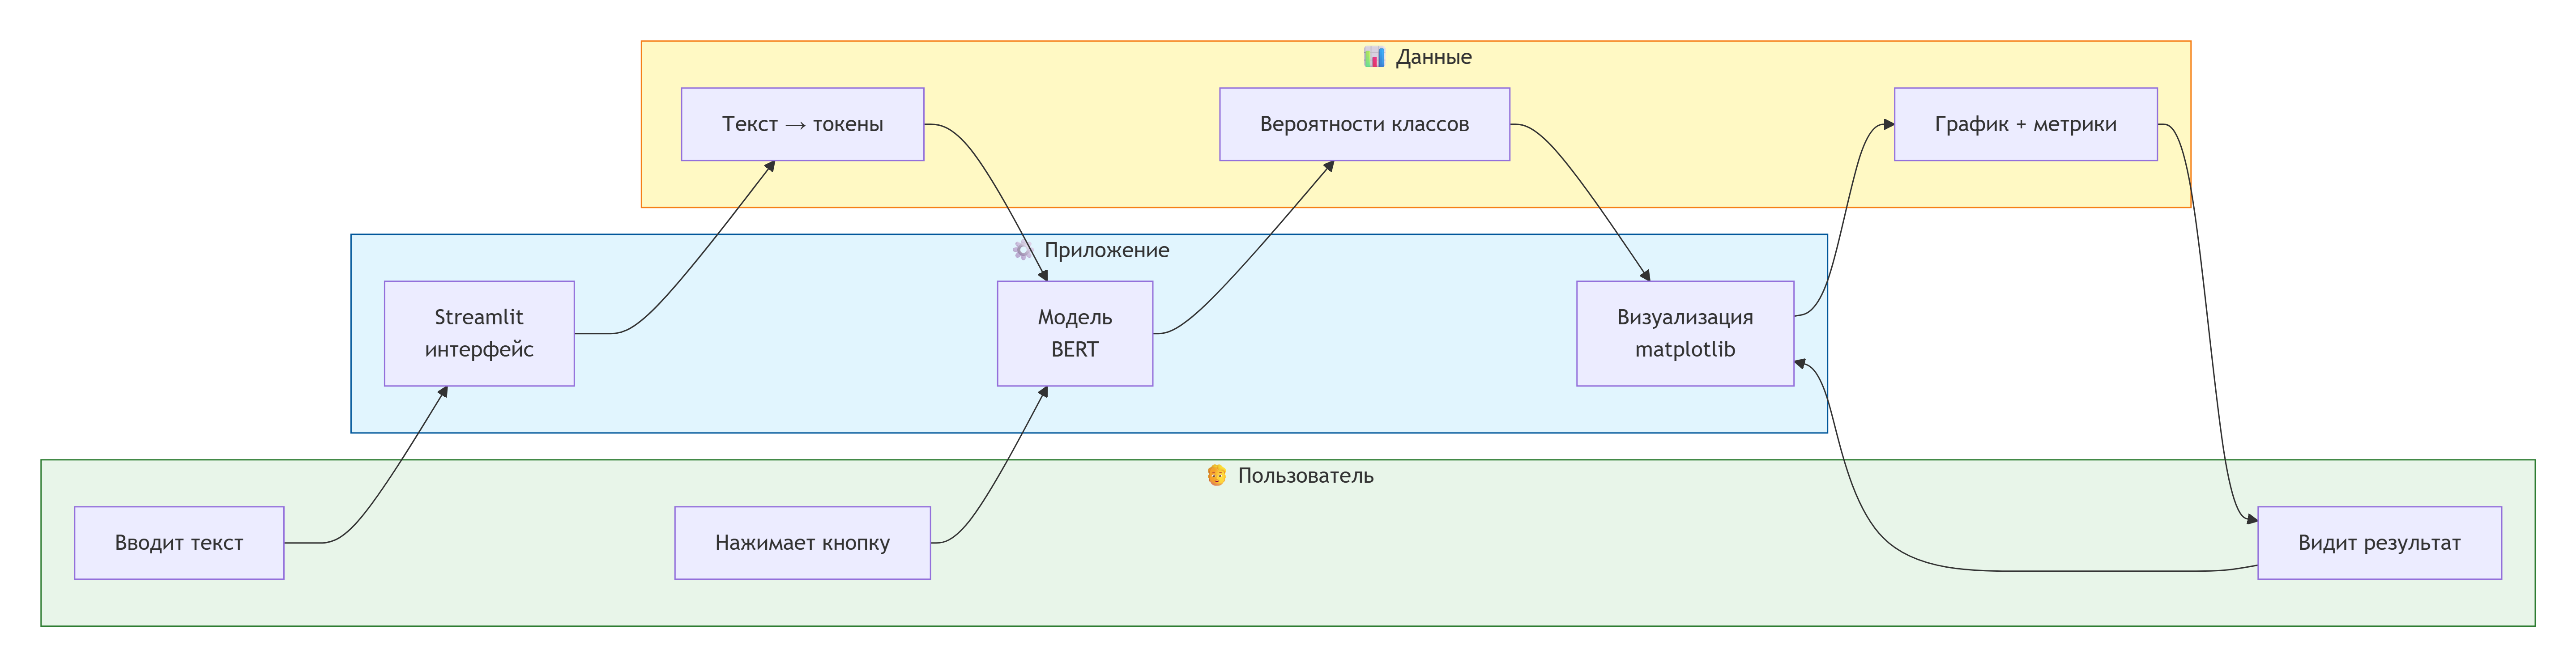


---

### 3.13. Частые ошибки и их решение

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `'streamlit' is not recognized` | Streamlit не установлен или не в PATH | `pip install streamlit`, перезапустите терминал |
| `No module named 'streamlit'` | Streamlit установлен в другом окружении | Активируйте виртуальное окружение |
| `FileNotFoundError: app.py` | Файл не найден | Проверьте, что вы в правильной папке и файл существует |
| `Address already in use` | Порт 8501 занят | Закройте другое приложение или используйте `streamlit run app.py --server.port 8502` |
| `ModuleNotFoundError: No module named 'transformers'` | Не установлена библиотека transformers | `pip install transformers` |
| `CUDA out of memory` | Не хватает памяти на GPU | Используйте `device=-1` (CPU) |
| `Model not found` | Модель не найдена по указанному пути | Проверьте путь к модели, скопируйте модель в `./models/best_model` |


# 4. ПРАКТИЧЕСКИЙ ПРИМЕР: ПОЛНОЦЕННОЕ ПРИЛОЖЕНИЕ ДЛЯ ПСИХОЛОГА

В предыдущих разделах мы создавали простое приложение для классификации эмоций. Теперь рассмотрим **реальный, полнофункциональный инструмент**, который может использовать психолог в своей работе.

---

## 4.1. Какие задачи решает это приложение

| Функция | Для чего психологу | Пример использования |
|---------|-------------------|---------------------|
| **Анализ тональности** | Оценка эмоционального фона текста пациента | Дневниковые записи, сообщения в чатах поддержки |
| **Суммаризация** | Сжатие длинных текстов до сути | Сокращение расшифровок сессий до ключевых моментов |
| **Перефразирование** | Проверка понимания, переформулировка | Пересказ слов пациента своими словами для проверки |
| **Исправление текста** | Редактирование записей | Исправление ошибок в быстрых заметках во время сессии |
| **Определение стиля** | Анализ характера высказываний | Определение, говорит ли пациент официально или эмоционально |
| **Генерация заголовка** | Организация заметок | Создание кратких названий для записей в дневнике пациента |

---

### 4.1.1. Клинические примеры использования

| Функция | Пример из практики | Что даёт психологу |
|---------|-------------------|-------------------|
| **Анализ тональности** | Пациент пишет в дневнике: *«Сегодня было терпимо, но вечером снова стало плохо»* | Модель определяет: негатив → сигнал для терапевта |
| **Суммаризация** | Расшифровка сессии на 10 страниц → 5 ключевых предложений | Терапевт быстро вспоминает основное содержание сессии |
| **Перефразирование** | Пациент говорит: *«Я не могу, я сломлен»* → *«Я чувствую себя истощённым и беспомощным»* | Проверка понимания: терапевт пересказывает слова пациента |
| **Исправление текста** | Быстрая заметка: *«Пациентка гаварит о страхе и бессонниче»* → *«Пациентка говорит о страхе и бессоннице»* | Чистые записи для истории болезни |
| **Определение стиля** | Текст пациента: *«Согласно моим наблюдениям, я испытываю...»* | Модель определяет: официально-деловой → пациент защищается |
| **Генерация заголовка** | Заметка о сессии → *«Сессия 12: работа с чувством вины»* | Удобная организация заметок о пациентах |

---

## 4.2. Чем этот пример отличается от предыдущего

| Аспект | Простое приложение (раздел 3.7) | Полноценное приложение (этот пример) |
|--------|-------------------------------|--------------------------------------|
| **Функциональность** | Только классификация эмоций | 6 различных NLP-задач |
| **Модель** | Локальная (ruBERT) | Облачная (через Hugging Face Inference API) |
| **Языки** | Только русский | Русский и английский (автоопределение) |
| **Интерфейс** | Две вкладки | Боковая панель с выбором функции |
| **Уровень сложности** | Базовый | Продвинутый |
| **Требования** | Нужна локальная модель | Нужен токен Hugging Face (бесплатный) |
| **Скорость работы** | Быстро (локально) | Зависит от интернета |
| **Объём кода** | ~150 строк | ~400 строк |

---

## 4.3. Как работает Hugging Face Inference API

**Что это:** вместо того чтобы загружать модель на свой компьютер (что требует много памяти и времени), мы отправляем запрос на сервер Hugging Face. Там модель уже загружена и готова к работе.

**Интуитивная аналогия:**

> Это как облачное хранение документов. Вы не храните файлы на своём компьютере, а загружаете их в облако. Так и здесь: модель живёт в облаке Hugging Face. Вы отправляете текст, а облако возвращает результат.

**Преимущества:**
- Не нужно загружать модель на свой компьютер.
- Работает даже на слабых компьютерах.
- Бесплатно (для небольших объёмов).

**Недостатки:**
- Нужен интернет.
- Есть ограничения по количеству запросов.
- Медленнее, чем локальная модель.




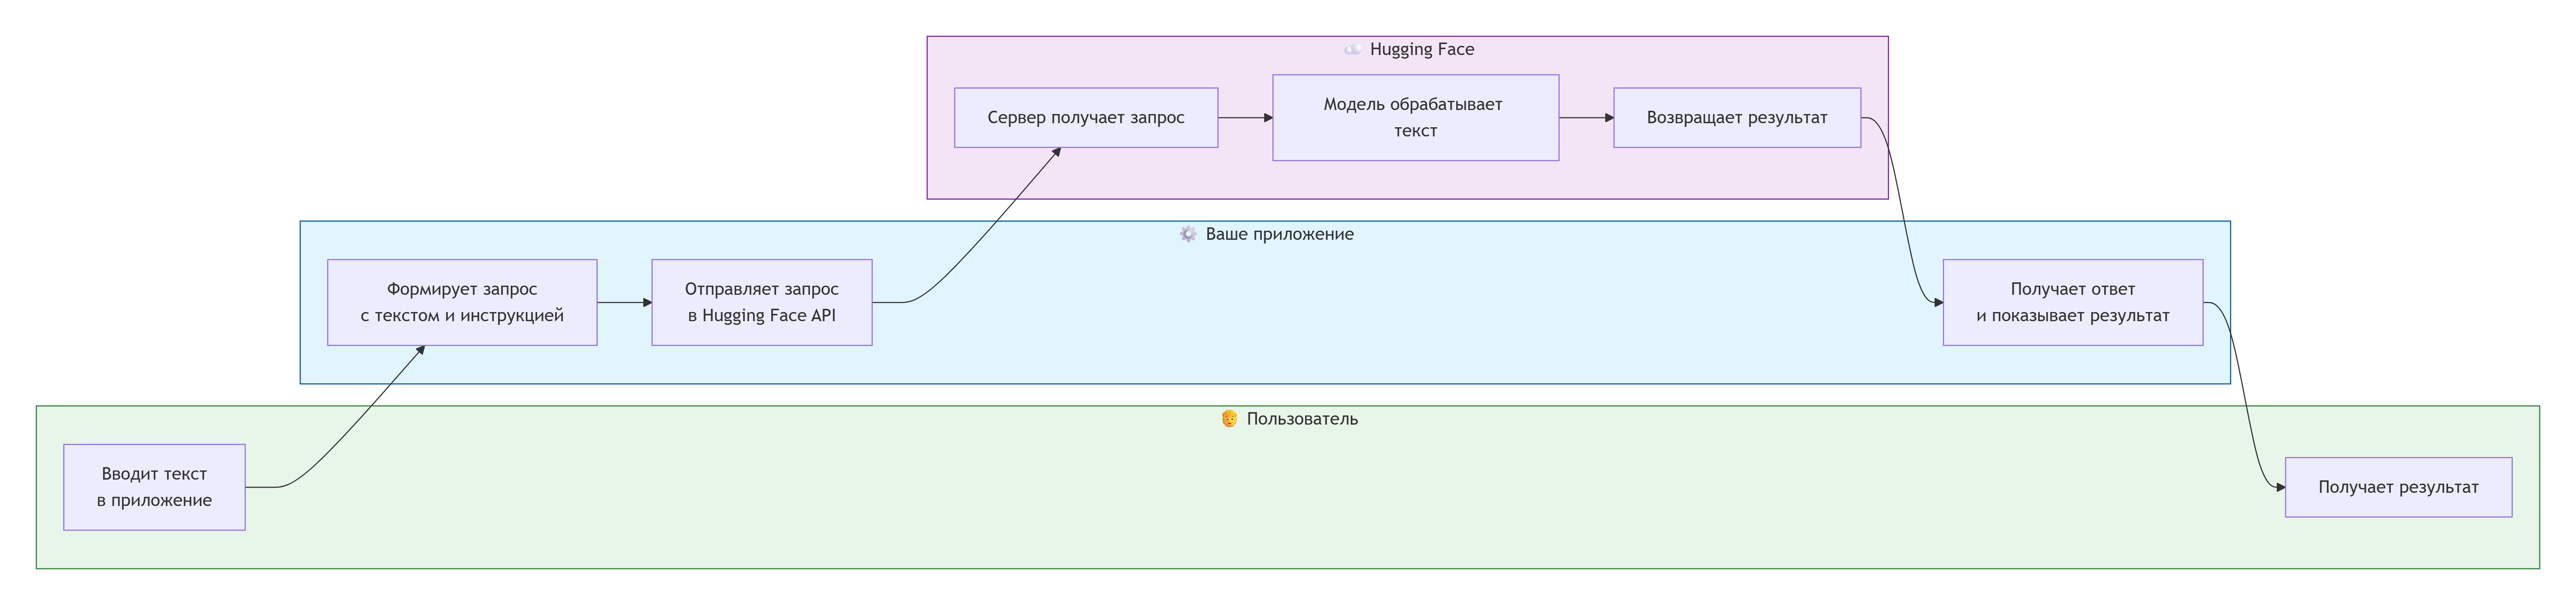


## 4.4. Подготовка: получение токена Hugging Face

Для работы с облачными моделями нужен бесплатный токен.

**Интуитивная аналогия:**

> Токен — это как ключ от кабинета. Чтобы войти в кабинет, нужно показать ключ. Hugging Face даёт вам бесплатный ключ, чтобы вы могли пользоваться их серверами для запуска моделей.

**Пошаговая инструкция:**

1. **Зарегистрируйтесь** на https://huggingface.co
2. **Перейдите в настройки:** нажмите на свой аватар → Settings
3. **Создайте токен:** Access Tokens → New Token → Read → Generate
4. **Скопируйте токен:** это длинная строка вида `hf_xxxxxx...`
5. **Сохраните в файл `.env`** в папке проекта:


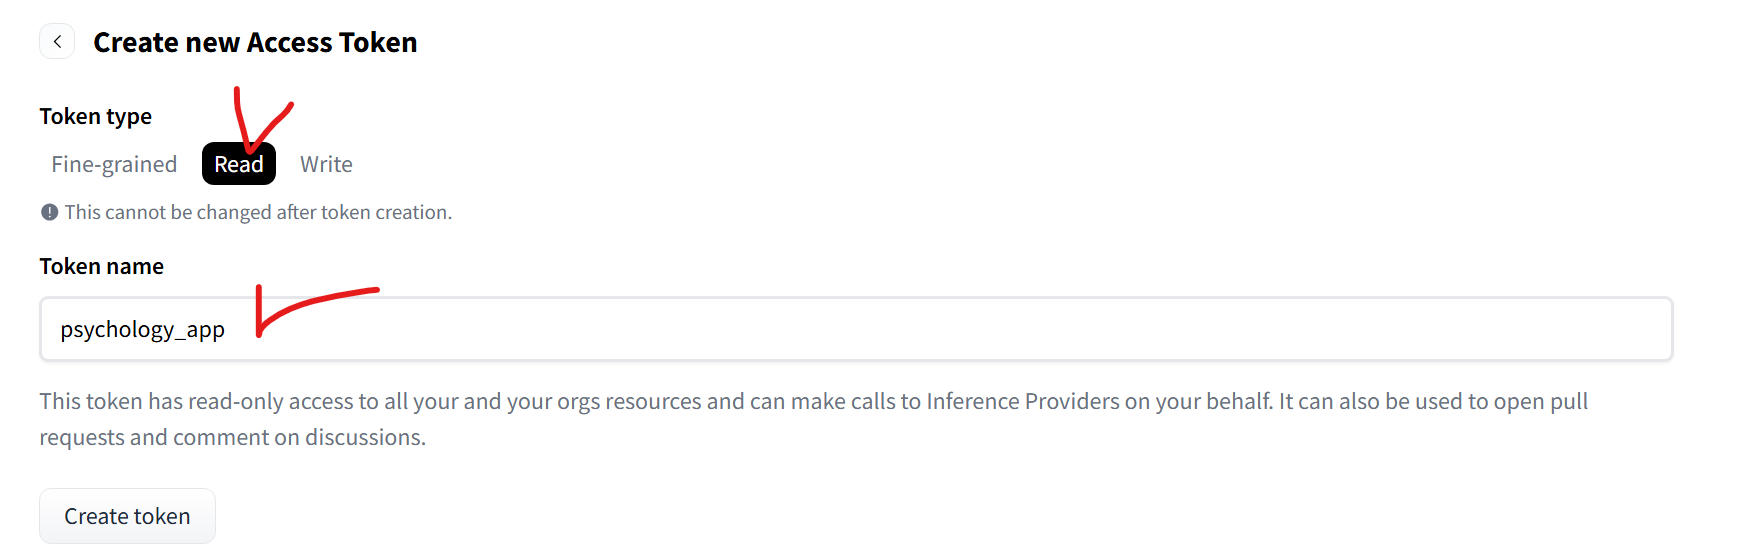


```bash
# Создайте файл .env и запишите токен
echo "HF_TOKEN=ваш_токен_сюда" > .env
```

**Важно:** файл `.env` нельзя загружать в GitHub или показывать другим — это ваш личный ключ.



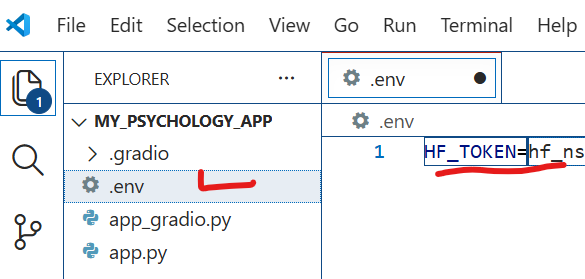

---

## 4.5. Схема архитектуры приложения




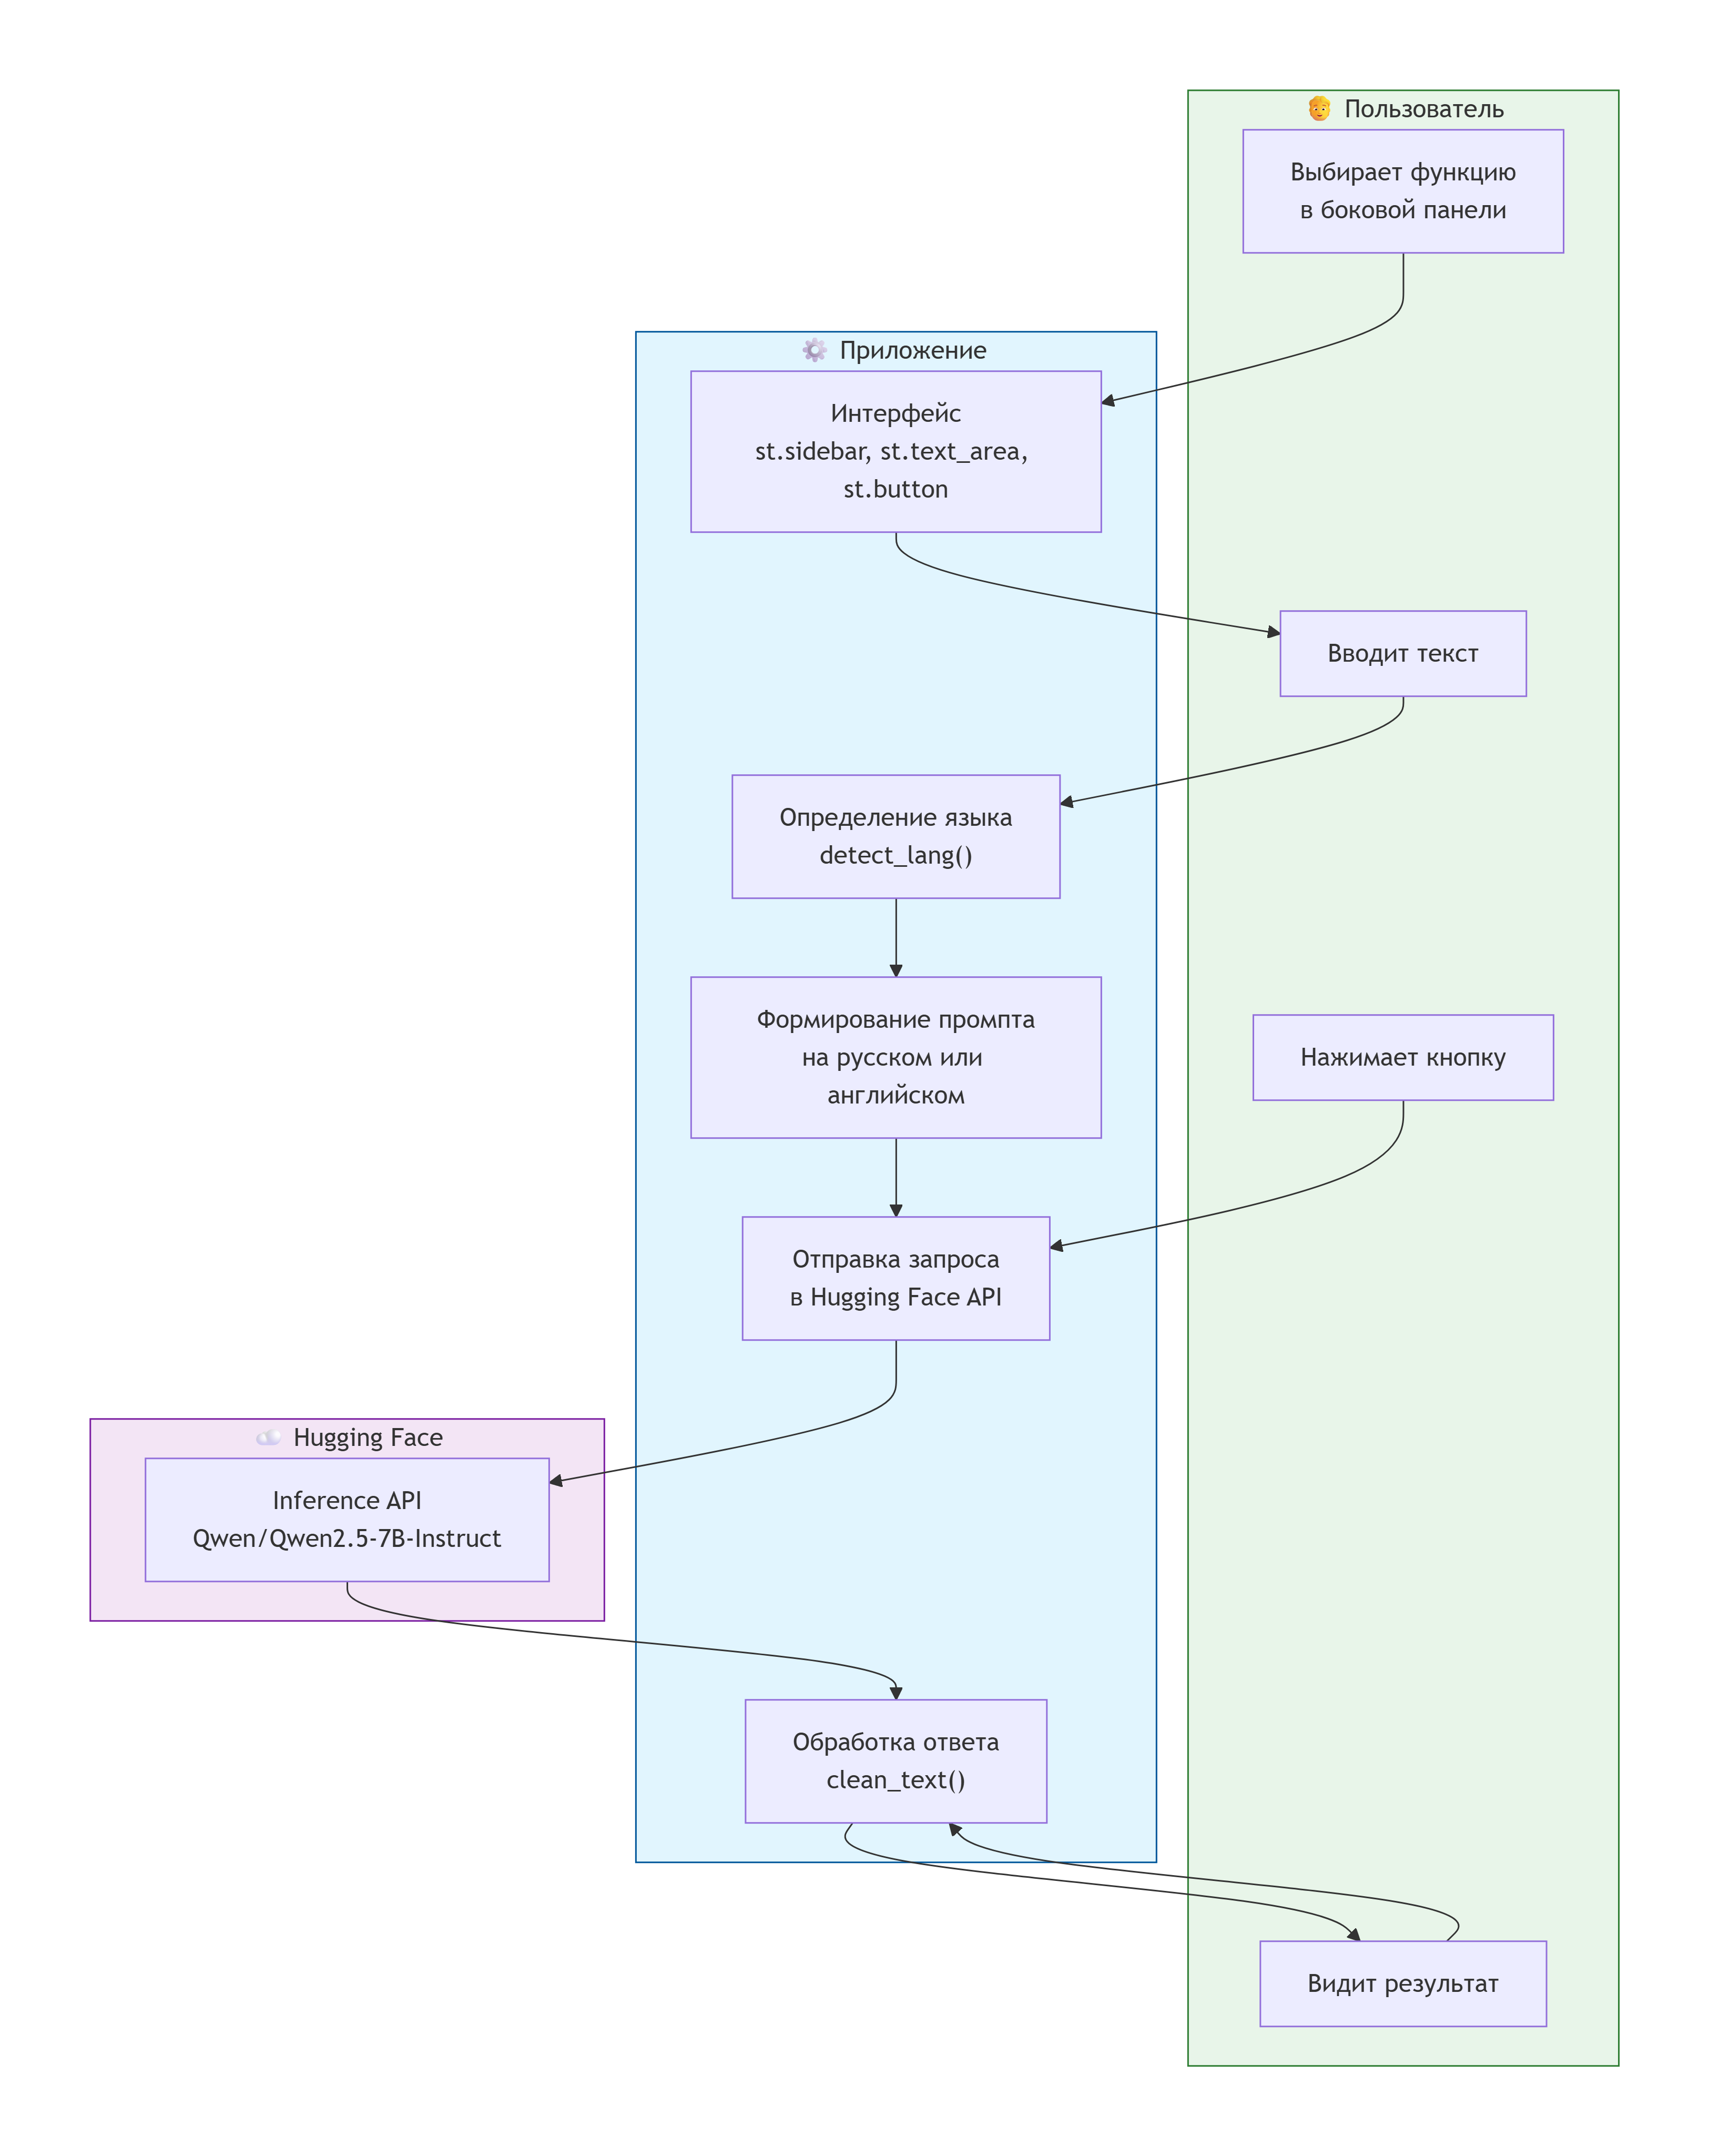


**Пояснение к схеме:**

1. **Пользователь** выбирает функцию в боковой панели, вводит текст и нажимает кнопку.
2. **Приложение** определяет язык текста (русский или английский).
3. **Приложение** формирует промпт (инструкцию) на нужном языке.
4. **Приложение** отправляет запрос в Hugging Face API.
5. **Hugging Face** обрабатывает текст с помощью модели Qwen.
6. **Приложение** получает ответ, очищает его и показывает пользователю.

---

## 4.6. Полный код приложения

```python
# ============================================================
# ПРИЛОЖЕНИЕ ДЛЯ ПСИХОЛОГА: NLP-ИНСТРУМЕНТАРИЙ
# ============================================================
#
# Это полноценное веб-приложение для работы с текстами пациентов.
# Оно решает 6 практических задач, полезных в работе психолога.
#
# Для запуска:
# 1. Установите библиотеки: pip install streamlit python-dotenv langdetect huggingface-hub
# 2. Получите бесплатный токен на huggingface.co
# 3. Создайте файл .env с токеном
# 4. Запустите: streamlit run app_psychology.py
# ============================================================

import os
import re
import streamlit as st
from dotenv import load_dotenv
from langdetect import detect, DetectorFactory
from huggingface_hub import InferenceClient

# ============================================================
# 1. КОНФИГУРАЦИЯ
# ============================================================

# Фиксируем случайность для детекции языка
DetectorFactory.seed = 0

# Загружаем переменные окружения (токен из .env файла)
load_dotenv()

# Настройка страницы
st.set_page_config(
    page_title="NLP-инструменты для психолога",
    page_icon="🧠",
    layout="centered"
)

# Заголовок приложения
st.title("🧠 NLP-инструменты для психолога")
st.caption(
    "Анализ текстов пациентов • Тональность • Суммаризация • "
    "Перефразирование • Исправление • Стиль • Заголовки"
)

# Получаем токен Hugging Face (из .env или из Streamlit Secrets)
HF_TOKEN = os.getenv("HF_TOKEN") or st.secrets.get("HF_TOKEN")

if not HF_TOKEN:
    st.error("❌ Не найден HF_TOKEN. Добавьте его в .env или Streamlit Secrets.")
    st.stop()

# ============================================================
# 2. ЗАГРУЗКА КЛИЕНТА (кешируется для скорости)
# ============================================================

@st.cache_resource
def get_client():
    """Создаёт клиент для работы с Hugging Face Inference API"""
    return InferenceClient(token=HF_TOKEN)

client = get_client()

# ============================================================
# 3. МОДЕЛИ
# ============================================================

# Модель для диалогов (генерирует текст)
# Qwen/Qwen2.5-7B-Instruct — мощная языковая модель от Alibaba,
# отлично работает с русским и английским языками
CHAT_MODEL = "Qwen/Qwen2.5-7B-Instruct"

# ============================================================
# 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def detect_lang(text: str) -> str:
    """
    Определяет язык текста (русский или английский).
    Психологу это нужно, чтобы правильно обрабатывать
    тексты пациентов на разных языках.
    """
    text = text.strip()
    
    # Проверяем наличие кириллицы
    if re.search(r"[а-яА-ЯёЁ]", text):
        return "ru"
    
    try:
        lang = detect(text)
        return "ru" if lang.startswith("ru") else "en"
    except Exception:
        return "en"

def clean_text(text: str) -> str:
    """
    Очищает ответ модели от служебных слов.
    Убирает "Ответ:", "Резюме:", "Заголовок:" и т.д.
    """
    text = text.strip()
    
    prefixes = [
        "Answer:", "Summary:", "In Russian:", "На русском:",
        "Ответ:", "Резюме:", "Краткое содержание:",
        "Исправленный текст:", "Перефразированный текст:",
        "Заголовок:", "Стиль:"
    ]
    
    for prefix in prefixes:
        if text.startswith(prefix):
            text = text.replace(prefix, "", 1).strip()
    
    # Убираем лишние переносы и пробелы
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    
    return text.strip()

def pretty_sentiment(label: str, lang: str) -> str:
    """
    Превращает метку тональности в красивое отображение с эмодзи.
    Для психолога это делает результаты более наглядными.
    """
    if lang == "ru":
        mapping = {
            "positive": "Позитив 😊",
            "neutral": "Нейтрально 😐",
            "negative": "Негатив 😡",
        }
    else:
        mapping = {
            "positive": "Positive 😊",
            "neutral": "Neutral 😐",
            "negative": "Negative 😡",
        }
    return mapping.get(label, label)

# ============================================================
# 5. ОСНОВНЫЕ NLP-ФУНКЦИИ
# ============================================================

def analyze_sentiment(text: str):
    """
    Анализирует тональность текста (позитив/нейтраль/негатив).
    Для психолога: помогает оценить эмоциональный фон пациента.
    """
    lang = detect_lang(text)
    text = text[:3000]  # ограничиваем длину для скорости
    
    if lang == "ru":
        prompt = f"""
Определи тональность текста.

Варианты:
- positive
- neutral
- negative

Правила:
- Официальные, новостные и информационные тексты без эмоций считай neutral.
- Не оценивай отдельные слова как негативные без общего негативного смысла.
- Верни ответ строго в формате:
label: positive/neutral/negative

Текст:
{text}
"""
    else:
        prompt = f"""
Detect the sentiment of the text.

Options:
- positive
- neutral
- negative

Rules:
- Official, news-like and informational texts without emotions should be neutral.
- Return strictly in this format:
label: positive/neutral/negative

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=80,
            temperature=0.0,  # 0.0 = минимальная случайность, точные ответы
        )
        
        result = response.choices[0].message.content.lower()
        
        if "positive" in result:
            label = "positive"
        elif "negative" in result:
            label = "negative"
        else:
            label = "neutral"
        
        return label, lang
    
    except Exception:
        return "neutral", lang

def summarize_text(text: str):
    """
    Создаёт краткое содержание длинного текста.
    Для психолога: сжатие расшифровок сессий до ключевых моментов.
    """
    lang = detect_lang(text)
    text = text[:9000]
    
    if lang == "ru":
        prompt = f"""
Сделай краткое содержание текста.

Правила:
- Только русский язык.
- 4-6 предложений.
- Только ключевые идеи.
- Без лишних слов.
- Не добавляй факты, которых нет в тексте.

Текст:
{text}
"""
    else:
        prompt = f"""
Summarize the text.

Rules:
- Use only English.
- 4-6 sentences.
- Only key ideas.
- Do not add facts that are not in the text.

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=280,
            temperature=0.2,
            top_p=0.85,
        )
        return clean_text(response.choices[0].message.content)
    except Exception as e:
        return f"Ошибка суммаризации: {str(e)}"

def paraphrase_text(text: str):
    """
    Перефразирует текст, сохраняя смысл.
    Для психолога: помогает проверить понимание пациента,
    пересказывая его слова своими словами.
    """
    lang = detect_lang(text)
    text = text[:6000]
    
    if lang == "ru":
        system_prompt = """
Ты профессиональный редактор русского текста.
Твоя задача — существенно перефразировать текст, сохранив его смысл.
"""
        user_prompt = f"""
Существенно перефразируй текст.

Требования:
- Сохрани исходный смысл и все факты.
- Максимально измени структуру предложений.
- Замени повторяющиеся формулировки синонимами.
- Не оставляй большие фрагменты исходного текста без изменений.
- Не добавляй новую информацию.
- Верни только перефразированный текст.

Текст:
{text}
"""
    else:
        system_prompt = """
You are a professional English text editor.
Your task is to substantially paraphrase the text while preserving its meaning.
"""
        user_prompt = f"""
Substantially paraphrase the text.

Requirements:
- Preserve the original meaning and all facts.
- Change sentence structure as much as possible.
- Replace obvious wording with synonyms.
- Do not leave large parts unchanged.
- Do not add new information.
- Return only the paraphrased text.

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            max_tokens=650,
            temperature=0.45,
            top_p=0.9,
        )
        return clean_text(response.choices[0].message.content)
    except Exception as e:
        return f"Ошибка перефразирования: {str(e)}"

def correct_text(text: str):
    """
    Исправляет ошибки в тексте.
    Для психолога: редактирование быстрых заметок во время сессии.
    """
    lang = detect_lang(text)
    text = text[:6000]
    
    if lang == "ru":
        prompt = f"""
Исправь ошибки в тексте на русском языке.

Правила:
- Исправь орфографию, пунктуацию и грамматику.
- Сохрани смысл текста.
- Не добавляй новые факты.
- Не сокращай текст.
- Верни только исправленный текст.

Текст:
{text}
"""
    else:
        prompt = f"""
Correct the text in English.

Rules:
- Fix spelling, punctuation and grammar.
- Preserve the original meaning.
- Do not add new facts.
- Do not shorten the text.
- Return only the corrected text.

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=450,
            temperature=0.1,
            top_p=0.8,
        )
        return clean_text(response.choices[0].message.content)
    except Exception as e:
        return f"Ошибка исправления текста: {str(e)}"

def detect_text_style(text: str):
    """
    Определяет стиль текста.
    Для психолога: помогает понять, как пациент говорит.
    """
    lang = detect_lang(text)
    text = text[:6000]
    
    if lang == "ru":
        prompt = f"""
Определи стиль текста.

Возможные стили:
- научный
- официально-деловой
- публицистический
- разговорный
- художественный
- нейтральный

Правила:
- Ответь только на русском языке.
- Укажи стиль текста.

Текст:
{text}
"""
    else:
        prompt = f"""
Detect the style of the text.

Possible styles:
- academic
- formal
- journalistic
- conversational
- literary
- neutral

Rules:
- Answer only in English.
- Name the style.

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=220,
            temperature=0.2,
            top_p=0.85,
        )
        return clean_text(response.choices[0].message.content)
    except Exception as e:
        return f"Ошибка определения стиля: {str(e)}"

def generate_title(text: str):
    """
    Создаёт заголовок для текста.
    Для психолога: помогает организовывать заметки о пациентах.
    """
    lang = detect_lang(text)
    text = text[:5000]
    
    if lang == "ru":
        system_prompt = """
Ты редактор научных и информационных текстов.
Твоя задача — создавать точные и информативные заголовки.
"""
        user_prompt = f"""
Создай заголовок для текста.

Требования:
- Заголовок должен отражать основную тему текста.
- Используй нейтральный и информативный стиль.
- Не делай заголовок слишком общим.
- Не придумывай новых смыслов.
- Не используй кликбейт.
- Длина: 3-8 слов.
- Верни только заголовок.

Текст:
{text}
"""
    else:
        system_prompt = """
You are an editor of scientific and informational texts.
Your task is to create accurate and informative titles.
"""
        user_prompt = f"""
Create a title for the text.

Requirements:
- The title must reflect the main topic.
- Use a neutral and informative style.
- Do not make the title too generic.
- Do not invent new meanings.
- No clickbait.
- Length: 3-8 words.
- Return only the title.

Text:
{text}
"""
    
    try:
        response = client.chat_completion(
            model=CHAT_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            max_tokens=40,
            temperature=0.15,
            top_p=0.8,
        )
        result = clean_text(response.choices[0].message.content)
        # убираем кавычки и переносы
        result = result.replace('"', "").replace("«", "").replace("»", "")
        result = result.split("\n")[0].strip()
        return result
    except Exception as e:
        return f"Ошибка генерации заголовка: {str(e)}"

# ============================================================
# 6. ПОЛЬЗОВАТЕЛЬСКИЙ ИНТЕРФЕЙС
# ============================================================

# Боковая панель с выбором задачи
task = st.sidebar.selectbox(
    "Выберите функцию",
    [
        "Анализ тональности",
        "Суммаризация",
        "Перефразирование",
        "Исправление текста",
        "Определение стиля",
        "Генерация заголовка",
    ]
)

# Информация о приложении в боковой панели
with st.sidebar:
    st.divider()
    st.caption("🔑 Нужен токен Hugging Face")
    st.caption("📚 Поддерживает русский и английский")
    st.caption("⚠️ Не является медицинским диагнозом")

# ============================================================
# 7. ИНТЕРФЕЙС ДЛЯ КАЖДОЙ ЗАДАЧИ
# ============================================================

if task == "Анализ тональности":
    st.subheader("🎭 Анализ тональности")
    st.caption("Оценивает эмоциональный фон текста: позитив/нейтраль/негатив")
    
    text = st.text_area(
        "Введите текст для анализа:",
        height=180,
        placeholder="Например: Я чувствую себя лучше, но всё ещё тревожно..."
    )
    
    if st.button("🔍 Анализировать"):
        if text.strip():
            with st.spinner("⏳ Анализируем текст..."):
                label, lang = analyze_sentiment(text)
            st.success("Готово!")
            st.write("**Тональность:**", pretty_sentiment(label, lang))
        else:
            st.warning("Пожалуйста, введите текст.")

elif task == "Суммаризация":
    st.subheader("📄 Суммаризация текста")
    st.caption("Сжимает длинный текст до 4-6 предложений с ключевыми идеями")
    
    text = st.text_area(
        "Вставьте длинный текст:",
        height=260,
        placeholder="Вставьте расшифровку сессии или заметку..."
    )
    
    if st.button("📝 Сжать текст"):
        if text.strip():
            with st.spinner("⏳ Суммаризируем текст..."):
                result = summarize_text(text)
            st.success("Готово!")
            st.write(result)
        else:
            st.warning("Пожалуйста, введите текст.")

elif task == "Перефразирование":
    st.subheader("🔁 Перефразирование текста")
    st.caption("Пересказывает текст другими словами, сохраняя смысл")
    
    text = st.text_area(
        "Введите текст для перефразирования:",
        height=240,
        placeholder="Введите текст, который нужно пересказать другими словами..."
    )
    
    if st.button("🔄 Перефразировать"):
        if text.strip():
            with st.spinner("⏳ Перефразируем текст..."):
                result = paraphrase_text(text)
            st.success("Готово!")
            st.write(result)
        else:
            st.warning("Пожалуйста, введите текст.")

elif task == "Исправление текста":
    st.subheader("📝 Исправление текста")
    st.caption("Исправляет орфографические, пунктуационные и грамматические ошибки")
    
    text = st.text_area(
        "Введите текст с ошибками:",
        height=240,
        placeholder="Например: Я хочю исправить этот текс для заметок..."
    )
    
    if st.button("✏️ Исправить"):
        if text.strip():
            with st.spinner("⏳ Исправляем текст..."):
                result = correct_text(text)
            st.success("Готово!")
            st.write(result)
        else:
            st.warning("Пожалуйста, введите текст.")

elif task == "Определение стиля":
    st.subheader("🎭 Определение стиля текста")
    st.caption("Определяет стиль: научный, официальный, разговорный и т.д.")
    
    text = st.text_area(
        "Введите текст для анализа стиля:",
        height=240,
        placeholder="Вставьте текст, стиль которого нужно определить..."
    )
    
    if st.button("🔍 Определить стиль"):
        if text.strip():
            with st.spinner("⏳ Анализируем стиль..."):
                result = detect_text_style(text)
            st.success("Готово!")
            st.write("**Определённый стиль:**", result)
        else:
            st.warning("Пожалуйста, введите текст.")

elif task == "Генерация заголовка":
    st.subheader("🏷️ Генерация заголовка")
    st.caption("Создаёт краткий, информативный заголовок для текста")
    
    text = st.text_area(
        "Введите текст для генерации заголовка:",
        height=260,
        placeholder="Вставьте текст заметки или протокола..."
    )
    
    if st.button("🏷️ Создать заголовок"):
        if text.strip():
            with st.spinner("⏳ Генерируем заголовок..."):
                result = generate_title(text)
            st.success("Готово!")
            st.write("**Заголовок:**", result)
        else:
            st.warning("Пожалуйста, введите текст.")

# ============================================================
# 8. ПОДВАЛ
# ============================================================

st.divider()
st.caption("⚠️ **Важное предупреждение:** Это демонстрационный инструмент, не медицинская диагностика. Результаты не являются диагнозом и не заменяют консультацию специалиста.")
st.caption("🔒 Ваши данные не сохраняются на сервере.")
```

---

## 4.7. Как запустить это приложение

**Пошаговая инструкция:**

1. **Создайте папку проекта** (см. раздел 3.2):

```bash
mkdir psych_nlp_app
cd psych_nlp_app
```

2. **Создайте файл `app.py`** и скопируйте в него код из раздела 4.6.

3. **Создайте файл `.env`** с вашим токеном Hugging Face:

```bash
echo "HF_TOKEN=ваш_токен_сюда" > .env
```

4. **Создайте файл `requirements.txt`**:

```txt
streamlit==1.28.0
python-dotenv==1.0.0
langdetect==1.0.9
huggingface-hub==0.20.0
```

5. **Установите библиотеки**:

```bash
pip install -r requirements.txt
```

6. **Запустите приложение**:

```bash
streamlit run app.py
```

7. **Откройте браузер** по адресу `http://localhost:8501`.

**Готово!** 🎉 Вы можете использовать приложение для анализа текстов пациентов.



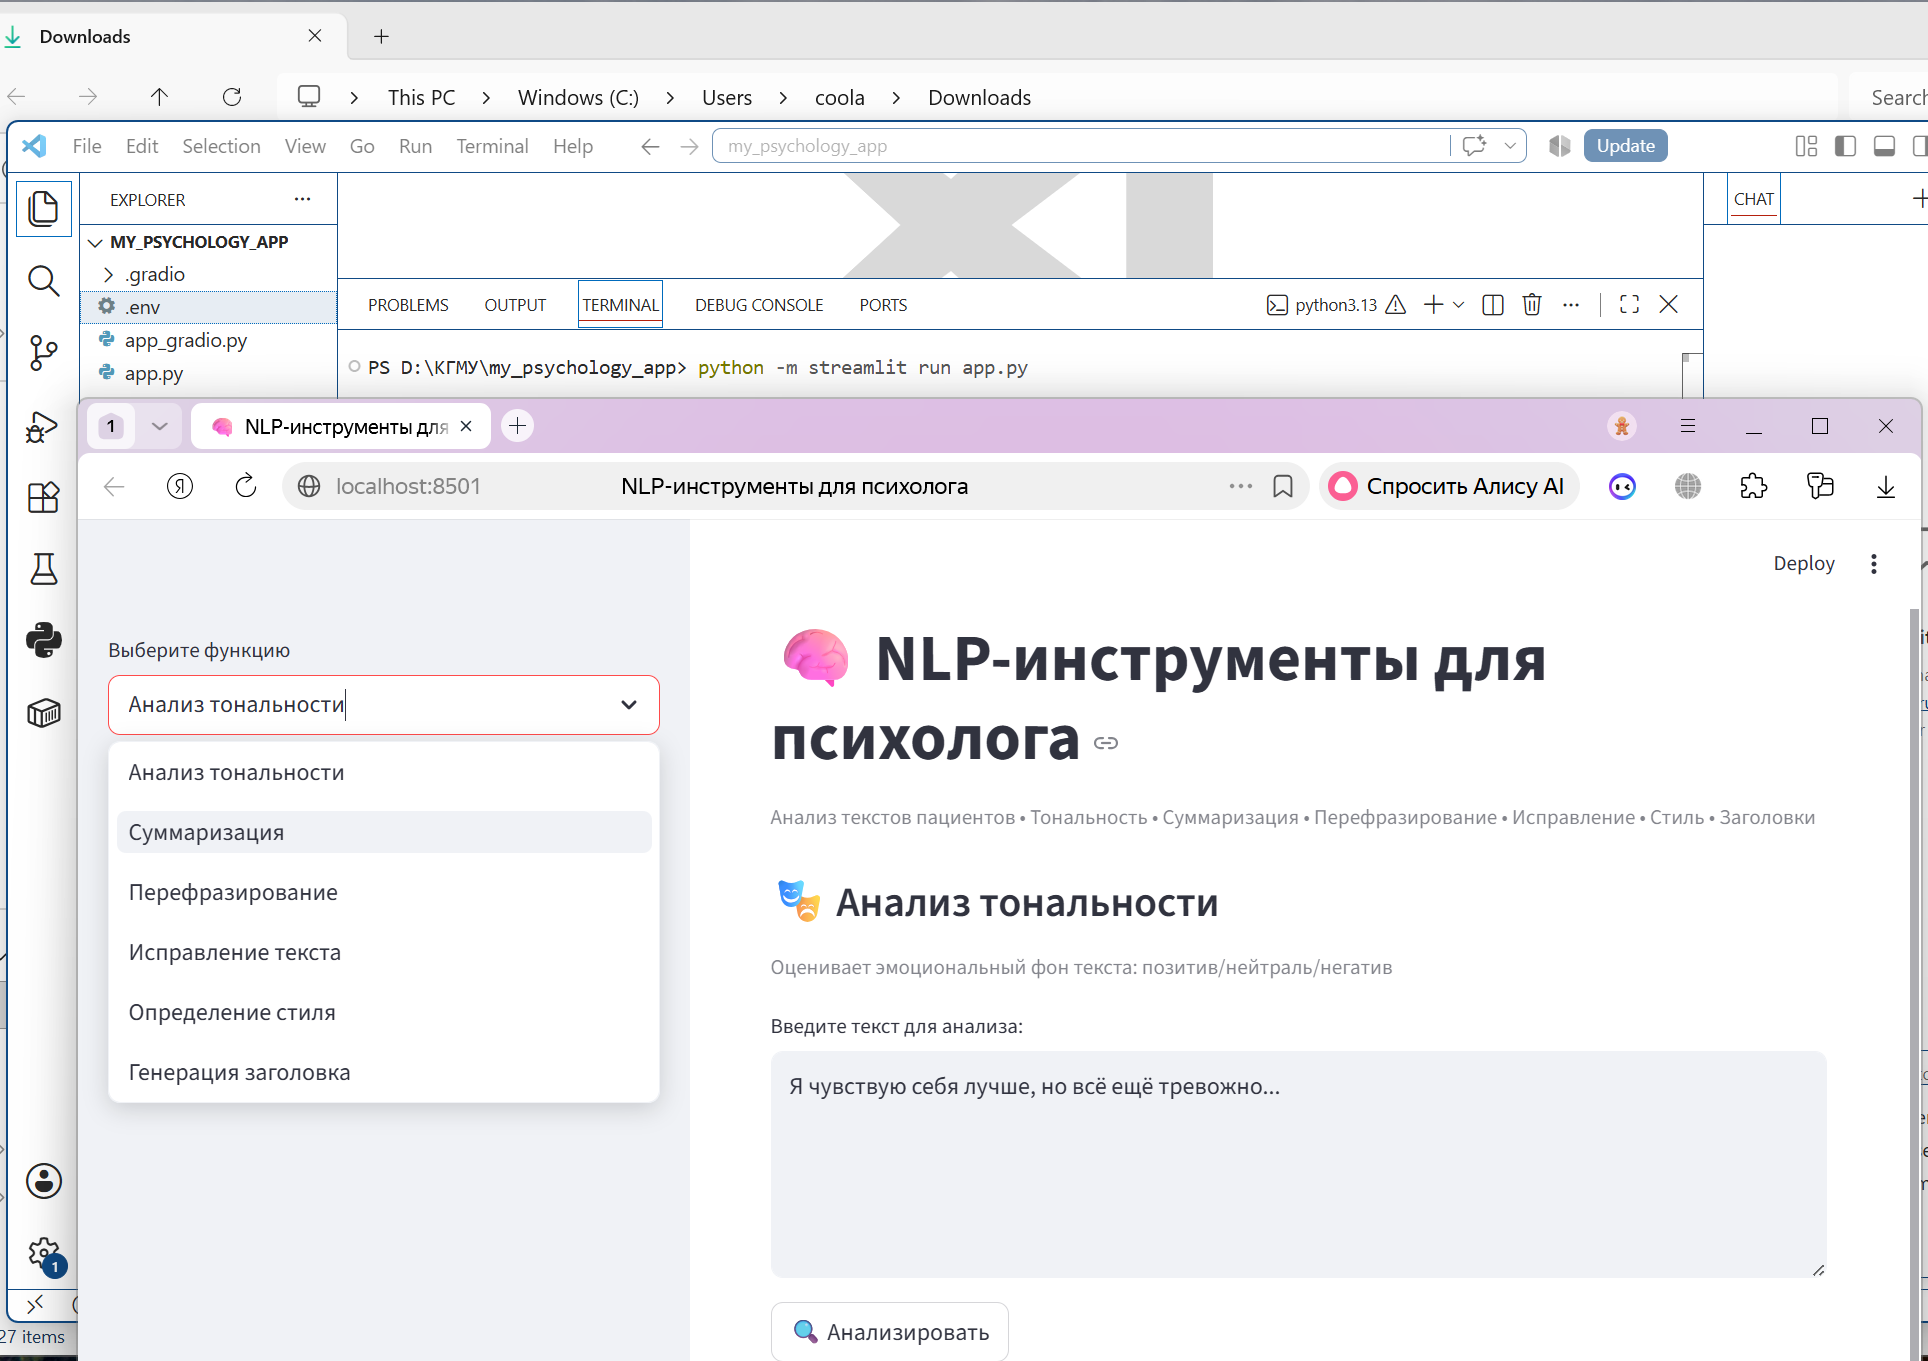



## 4.8. Частые ошибки и их решение

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `HF_TOKEN not found` | Токен не добавлен в `.env` | Проверьте файл `.env`, убедитесь, что токен записан без кавычек |
| `Rate limit exceeded` | Слишком много запросов | Подождите несколько минут, затем повторите |
| `Connection timeout` | Нет интернета или проблемы с Hugging Face | Проверьте интернет-соединение, попробуйте позже |
| `Model not loaded` | Модель Qwen недоступна | Подождите или попробуйте другую модель |
| `'langdetect' not found` | Библиотека не установлена | `pip install langdetect` |
| `'dotenv' not found` | Библиотека не установлена | `pip install python-dotenv` |
| `Streamlit not found` | Streamlit не установлен | `pip install streamlit` |

---

## 4.9. Основные выводы раздела

1. **Полноценное приложение для психолога** может решать 6 практических задач: анализ тональности, суммаризация, перефразирование, исправление текста, определение стиля, генерация заголовка.

2. **Hugging Face Inference API** позволяет использовать мощные модели без загрузки их на свой компьютер — достаточно бесплатного токена.

3. **Мультиязычность** — приложение автоматически определяет язык текста (русский или английский) и формирует запрос на нужном языке.

4. **Кеширование** — клиент Hugging Face загружается один раз с помощью `@st.cache_resource`, что ускоряет работу.

5. **Этический аспект** — приложение содержит дисклеймер о недиагностическом назначении и предупреждение о конфиденциальности данных.

6. **Этот пример показывает**, как можно создать реальный инструмент для психологической практики, используя современные NLP-модели и веб-фреймворк Streamlit.


# 5. ОБЛАЧНЫЙ ДЕПЛОЙ: STREAMLIT COMMUNITY CLOUD

После того как вы создали приложение и проверили его локально, наступает важный этап — **публикация в интернете**. Это позволит вашим коллегам, пациентам или исследовательской группе пользоваться приложением без установки Python и библиотек.

**Интуитивная аналогия:**

> Представьте, что вы разработали новый опросник. Сначала вы распечатали его и проверили на себе (локальный запуск). Теперь вы хотите, чтобы другие психологи могли им пользоваться. Для этого вы публикуете опросник в интернете (облачный деплой). Так и с приложением: облачный деплой — это публикация вашего инструмента в интернете, чтобы им могли пользоваться другие.

---

## 5.1. Что такое облачный деплой и зачем он нужен

**Определение:** облачный деплой — это процесс размещения вашего приложения на удалённых серверах, чтобы оно было доступно через интернет по постоянной ссылке.

**Преимущества облачного деплоя:**

| Преимущество | Объяснение |
|--------------|------------|
| **Доступность 24/7** | Приложение работает постоянно, без перерывов |
| **Доступ с любого устройства** | Пользователи могут открыть приложение в браузере с телефона, планшета, компьютера |
| **Без установки** | Пользователям не нужно устанавливать Python или библиотеки |
| **Простота распространения** | Достаточно отправить ссылку коллегам или пациентам |
| **Автоматические обновления** | При обновлении кода на GitHub приложение автоматически перезагружается |

---

## 5.2. Подготовка к деплою — чек-лист

Перед тем как выложить приложение в интернет, проверьте всё по списку:

| Что проверить | Как проверить | Почему важно |
|---------------|---------------|--------------|
| ✅ `app.py` есть | Файл существует в корне | Главная точка входа |
| ✅ `requirements.txt` есть | Все библиотеки перечислены | Без них приложение не запустится |
| ✅ Модель загружается | `@st.cache_resource` добавлен | Без кеширования — долгая загрузка |
| ✅ Пути к модели корректны | Используйте относительные пути | На сервере пути отличаются |
| ✅ Приложение работает локально | `streamlit run app.py` | Проверка перед деплоем |
| ✅ `.env` НЕ загружен в GitHub | Проверьте `.gitignore` | Токены не должны быть публичными |
| ✅ `README.md` есть | Описание проекта | Помогает пользователям |

---

## 5.3. Пошаговая инструкция деплоя




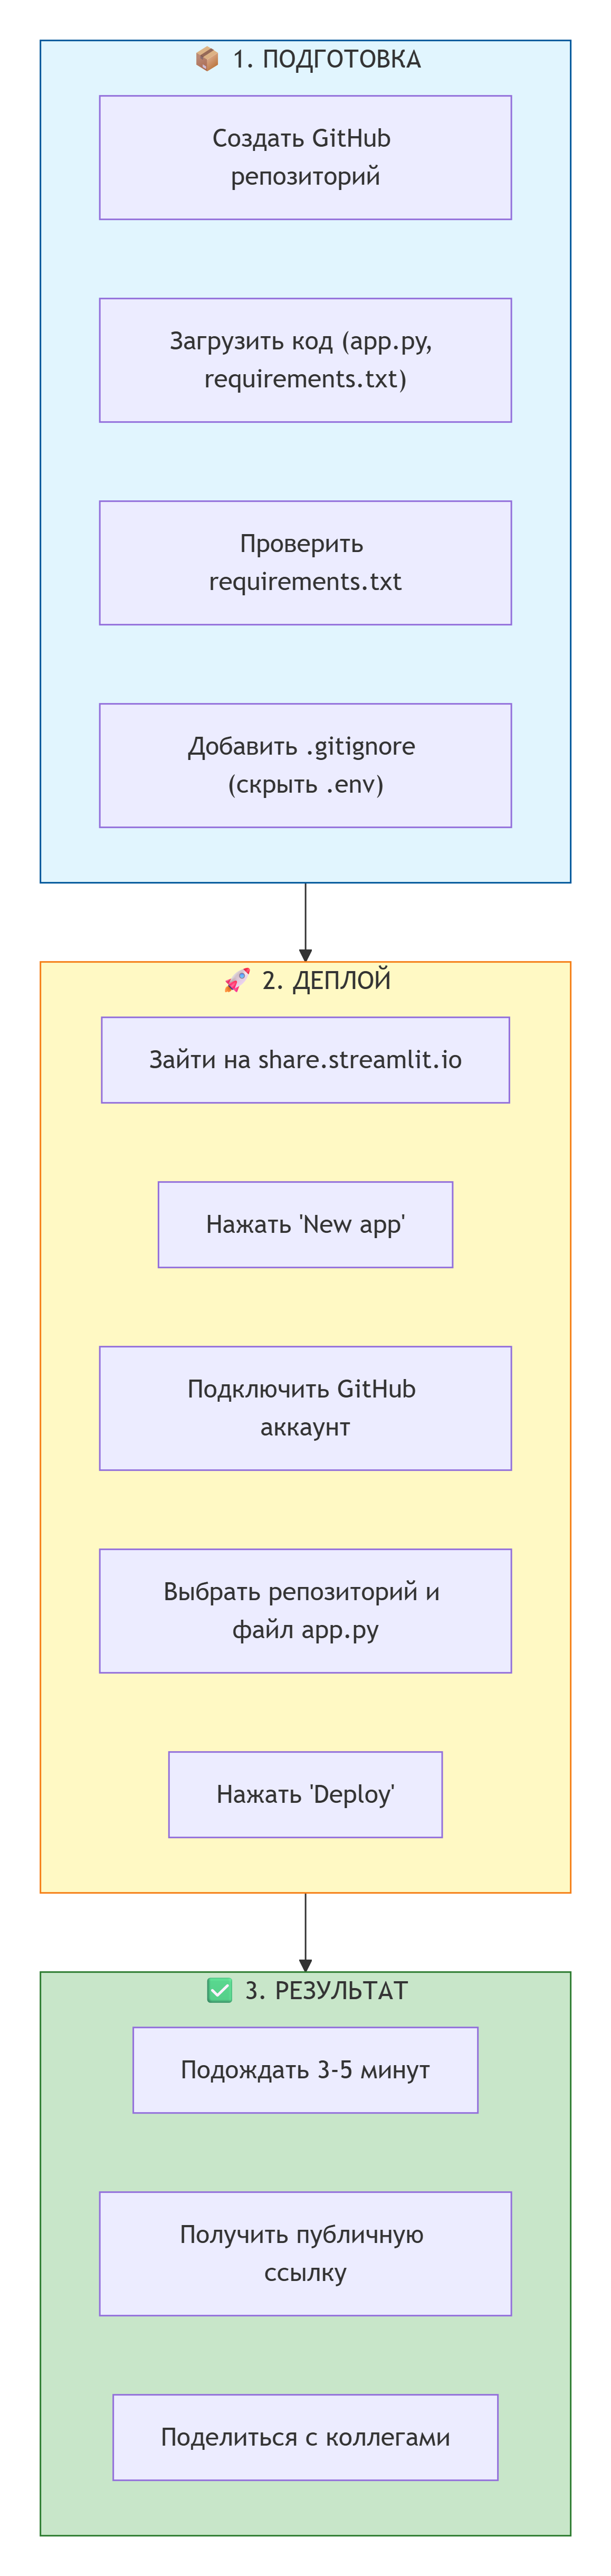



**Детальная инструкция:**

### Шаг 1: Создайте GitHub-репозиторий

1. **Зарегистрируйтесь на GitHub** (если ещё нет): https://github.com/join
2. **Создайте новый репозиторий:**
   - Нажмите на зелёную кнопку "New repository"
   - Назовите его (например, `emotion-analyzer`)
   - Выберите "Public" (публичный) — это бесплатно
   - Нажмите "Create repository"

### Шаг 2: Загрузите код в репозиторий

**Через VS Code (рекомендуется для новичков):**

1. Откройте папку проекта в VS Code.
2. Нажмите на иконку Source Control (ветка) в левой панели.
3. Нажмите "Initialize Repository" (инициализировать репозиторий).
4. Напишите сообщение коммита: "Initial commit".
5. Нажмите галочку (✓) для коммита.
6. Нажмите на иконку "Publish Branch" (опубликовать ветку).
7. Выберите "Public" репозиторий.

**Через командную строку (альтернативный способ):**

```bash
# Инициализация репозитория
git init

# Добавление всех файлов
git add app.py requirements.txt utils/ models/

# Создание коммита
git commit -m "Initial commit"

# Подключение к удалённому репозиторию
git remote add origin https://github.com/ваш_username/emotion-analyzer.git

# Отправка кода
git push -u origin main
```

### Шаг 3: Создайте файл `.gitignore`

Файл `.gitignore` указывает Git, какие файлы НЕ нужно загружать в репозиторий.

```bash
# Создайте файл .gitignore в корне проекта
echo ".env" > .gitignore
echo "__pycache__/" >> .gitignore
echo "*.pyc" >> .gitignore
echo ".DS_Store" >> .gitignore
echo "*.log" >> .gitignore
```

**Почему это важно:** файл `.env` содержит ваш секретный токен. Если вы загрузите его на GitHub, любой сможет его увидеть и использовать.

### Шаг 4: Настройка Streamlit Secrets

Для приложений, которые используют токены (как наш пример с Hugging Face), нужно добавить секреты в Streamlit Cloud.

**Как добавить секреты:**

1. После деплоя зайдите в ваш проект на Streamlit Cloud.
2. Нажмите на три точки (⋮) → "Settings" → "Secrets".
3. Добавьте ваш токен в формате:

```toml
HF_TOKEN = "hf_ваш_токен_сюда"
```

4. Нажмите "Save".

**В коде это работает так:**

```python
# Получаем токен из секретов Streamlit Cloud
HF_TOKEN = st.secrets.get("HF_TOKEN")
```

**Интуитивная аналогия:**

> Secrets — это как сейф в кабинете. Вы не храните ключи от сейфа на видном месте, а держите их в надёжном месте. Secrets защищают ваши токены от посторонних.

### Шаг 5: Зайдите на Streamlit Cloud

1. Откройте https://share.streamlit.io
2. Нажмите "New app" (зелёная кнопка).
3. Подключите ваш GitHub аккаунт (если ещё не подключили).
4. Выберите репозиторий и файл `app.py`.

**Обратите внимание:** если ваше приложение использует токены (как пример с Hugging Face), убедитесь, что вы добавили их в Secrets перед деплоем.

### Шаг 6: Нажмите Deploy

1. Нажмите "Deploy" (развернуть).
2. Подождите 3–5 минут — Streamlit Cloud загружает зависимости, устанавливает библиотеки и запускает приложение.
3. Получите публичную ссылку, например: `https://emotion-analyzer-username.streamlit.app`

**Готово!** 🎉 Ваше приложение доступно в интернете. Теперь вы можете поделиться ссылкой с коллегами.

---

## 5.4. Частые ошибки при деплое и их решение

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `ModuleNotFoundError` | Библиотека не указана в requirements.txt | Добавьте библиотеку в `requirements.txt` |
| `FileNotFoundError` | Файл не найден на сервере | Используйте относительные пути, проверьте регистр имён файлов |
| `Model not found` | Модель не загружена | Проверьте путь к модели, используйте `@st.cache_resource` |
| `HF_TOKEN not found` | Токен не добавлен в Secrets | Добавьте токен в Streamlit Secrets |
| `Memory limit exceeded` | Модель слишком большая | Используйте лёгкую модель или Hugging Face Spaces |
| `Timeout` | Приложение загружается слишком долго | Уменьшите размер модели, используйте кеширование |
| `Deploy failed` | Ошибка в коде | Проверьте логи (Logs) в Streamlit Cloud |

---

## 5.5. Ограничения бесплатного тарифа Streamlit Cloud (2026 год)

| Ограничение | Значение | Что это значит для психолога |
|-------------|----------|------------------------------|
| **Память (RAM)** | 1 GB | Модель должна быть < 700 MB. Подходят: ruBERT, DistilBERT, TinyBERT |
| **Процессор** | 1 CPU (средняя мощность) | Приложение работает медленнее, чем на мощном ПК. Для простых задач достаточно |
| **Время работы** | Без ограничений | Приложение доступно 24/7, 365 дней в году |
| **Хранилище** | 10 GB | Достаточно для модели, данных и логов |
| **Количество приложений** | Неограниченно | Можно создавать сколько угодно приложений |
| **Количество пользователей** | Без ограничений | Любое количество пользователей может открыть приложение |

**Что делать, если модель слишком большая (>1 GB):**

| Решение | Как работает | Для кого |
|---------|--------------|----------|
| **Hugging Face Spaces** | Бесплатный GPU (4-16 GB RAM) | Для больших моделей (Llama, GPT) |
| **Лёгкая модель** | Использовать DistilBERT, TinyBERT | Для экономии памяти |
| **Inference API** | Модель не хранится локально | Для приложений с интернетом |
| **Платный тариф** | Streamlit Cloud для бизнеса ($50/мес) | Для профессиональных проектов |

---

## 5.6. Альтернативный деплой: Hugging Face Spaces




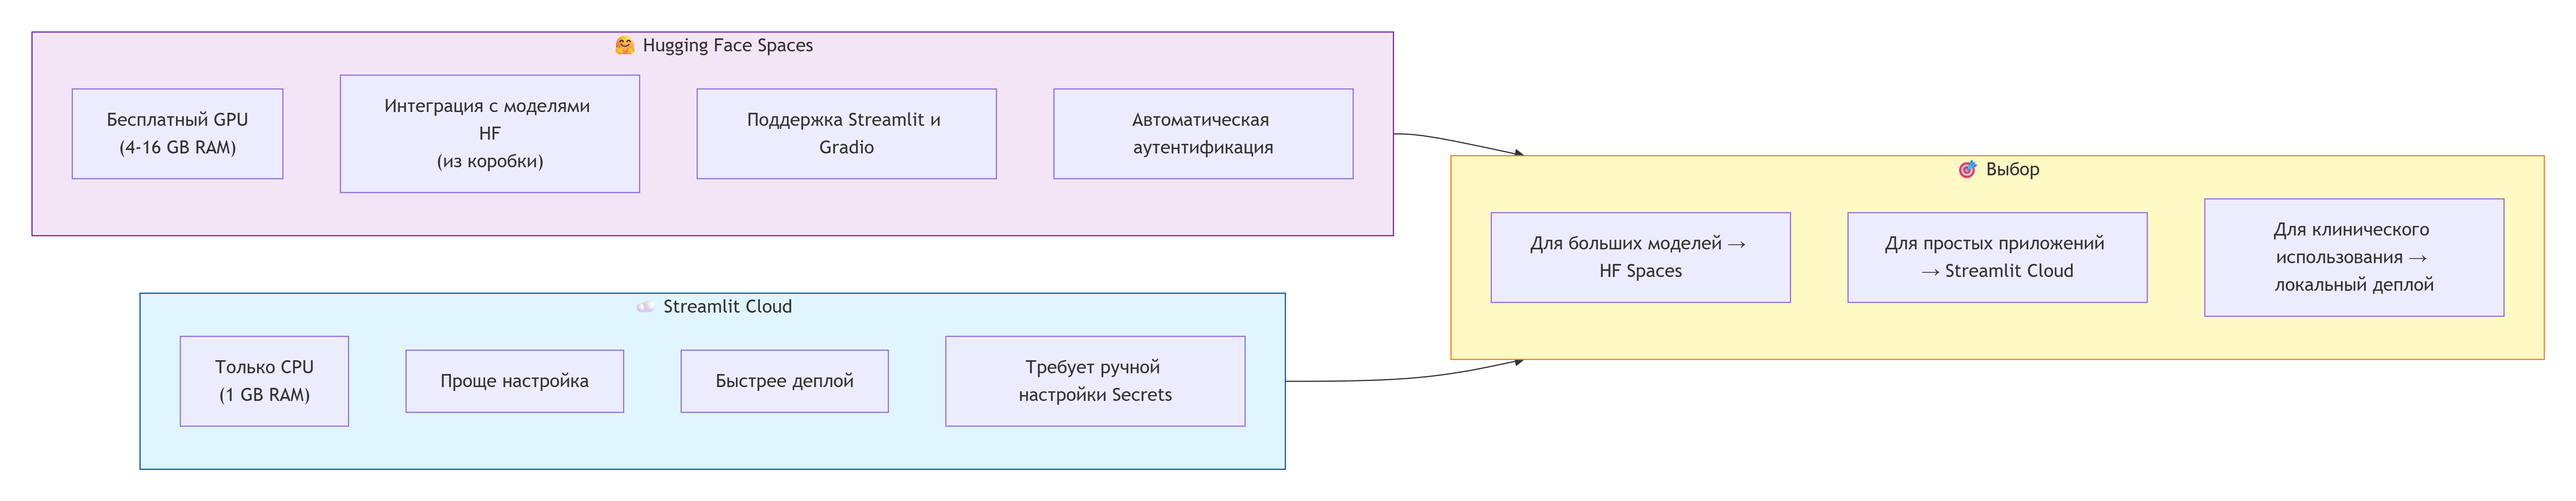



**Как деплоить на Hugging Face Spaces:**

1. Зайдите на https://huggingface.co/new-space
2. Выберите "Streamlit" или "Gradio" как SDK.
3. Назовите пространство (например, `emotion-analyzer`).
4. Загрузите файлы: `app.py`, `requirements.txt`, `utils/`, `models/`.
5. Нажмите "Create Space".
6. Через 2–3 минуты приложение доступно по ссылке.

**Преимущества Hugging Face Spaces:**

- Бесплатный GPU (для больших моделей).
- Простая интеграция с моделями Hugging Face.
- Не нужно настраивать Secrets — токены передаются автоматически.

---

## 5.7. Сравнение платформ для деплоя

| Критерий | Streamlit Cloud | Hugging Face Spaces | Локальный деплой |
|----------|-----------------|---------------------|------------------|
| **Бесплатно** | ✅ Да | ✅ Да | ✅ Да |
| **CPU/GPU** | CPU (1 GB RAM) | CPU или GPU (до 16 GB) | Ваш компьютер |
| **Сложность** | Очень низкая | Низкая | Высокая |
| **Настройка Secrets** | Ручная (Streamlit Secrets) | Автоматическая | Не требуется |
| **Поддержка больших моделей** | ❌ Нет | ✅ Да (GPU) | Зависит от ПК |
| **Время деплоя** | 3–5 минут | 2–3 минуты | Мгновенно |
| **Где использовать** | Простые приложения | Большие модели | Конфиденциальные данные |

---

## 5.8. Практические рекомендации для психологов

| Ситуация | Рекомендация | Почему |
|----------|--------------|--------|
| **Демонстрация коллегам** | Streamlit Cloud или Hugging Face Spaces | Быстро, бесплатно, доступно |
| **Использование в клинике с реальными данными** | **Только локальный деплой** | Конфиденциальность данных |
| **Большая модель (Llama, GPT)** | Hugging Face Spaces с GPU | Бесплатный GPU |
| **Простое приложение (классификация эмоций)** | Streamlit Cloud | Проще настройка |
| **Конфиденциальные данные пациентов** | Локальный деплой | Данные не покидают ваш компьютер |
| **Исследовательский проект** | Hugging Face Spaces | Интеграция с HF, публикация |

**Интуитивная аналогия:**

> - **Streamlit Cloud** — это как публикация статьи в открытом журнале. Быстро, доступно, но данные видны всем.
> - **Hugging Face Spaces** — это как публикация в специализированном журнале с рецензентами. Больше возможностей для сложных моделей.
> - **Локальный деплой** — это как хранение записей пациентов в закрытом кабинете. Безопасно, но доступно только вам.

---

## 5.9. Основные выводы раздела

1. **Облачный деплой** — это публикация вашего приложения в интернете, чтобы другие могли им пользоваться без установки программ.

2. **Streamlit Cloud** — самый простой способ деплоя для небольших приложений. Бесплатно, 3–5 минут, публичная ссылка.

3. **Hugging Face Spaces** — альтернатива с поддержкой GPU, идеальна для больших моделей.

4. **Для работы с реальными данными пациентов используйте локальный деплой** — данные не должны покидать ваш компьютер.

5. **Streamlit Secrets** — безопасное хранение токенов и паролей. Никогда не загружайте `.env` файл в репозиторий!

6. **Git и GitHub** — необходимые инструменты для деплоя. Научитесь базовым командам: `git add`, `git commit`, `git push`.

7. **Всегда проверяйте приложение локально перед деплоем.** Это сэкономит время и нервы.



## 6. ЭТИЧЕСКИЙ АСПЕКТ: КОНФИДЕНЦИАЛЬНОСТЬ И ОТВЕТСТВЕННОСТЬ

### 6.1. Что нельзя загружать в облачные сервисы

| ❌ НЕЛЬЗЯ | ✅ МОЖНО |
|-----------|----------|
| ФИО, адреса, телефоны пациентов | Синтетические данные (сгенерированные) |
| Данные, по которым можно идентифицировать человека | Анонимизированные данные (без идентификаторов) |
| Реальные истории болезней без согласия | Вымышленные примеры для демонстрации |
| Медицинские записи с датами рождения | Данные, обработанные через локальный деплой |

**Интуитивная аналогия:**

> Представьте, что вы — психолог в коворкинге. Вы можете обсуждать общие случаи (без имён), но не можете раскладывать на столе карточки с ФИО пациентов. Облачные сервисы — это тот же коворкинг: удобно, но нужно соблюдать конфиденциальность.

### 6.2. Этический чек-лист для психолога-разработчика




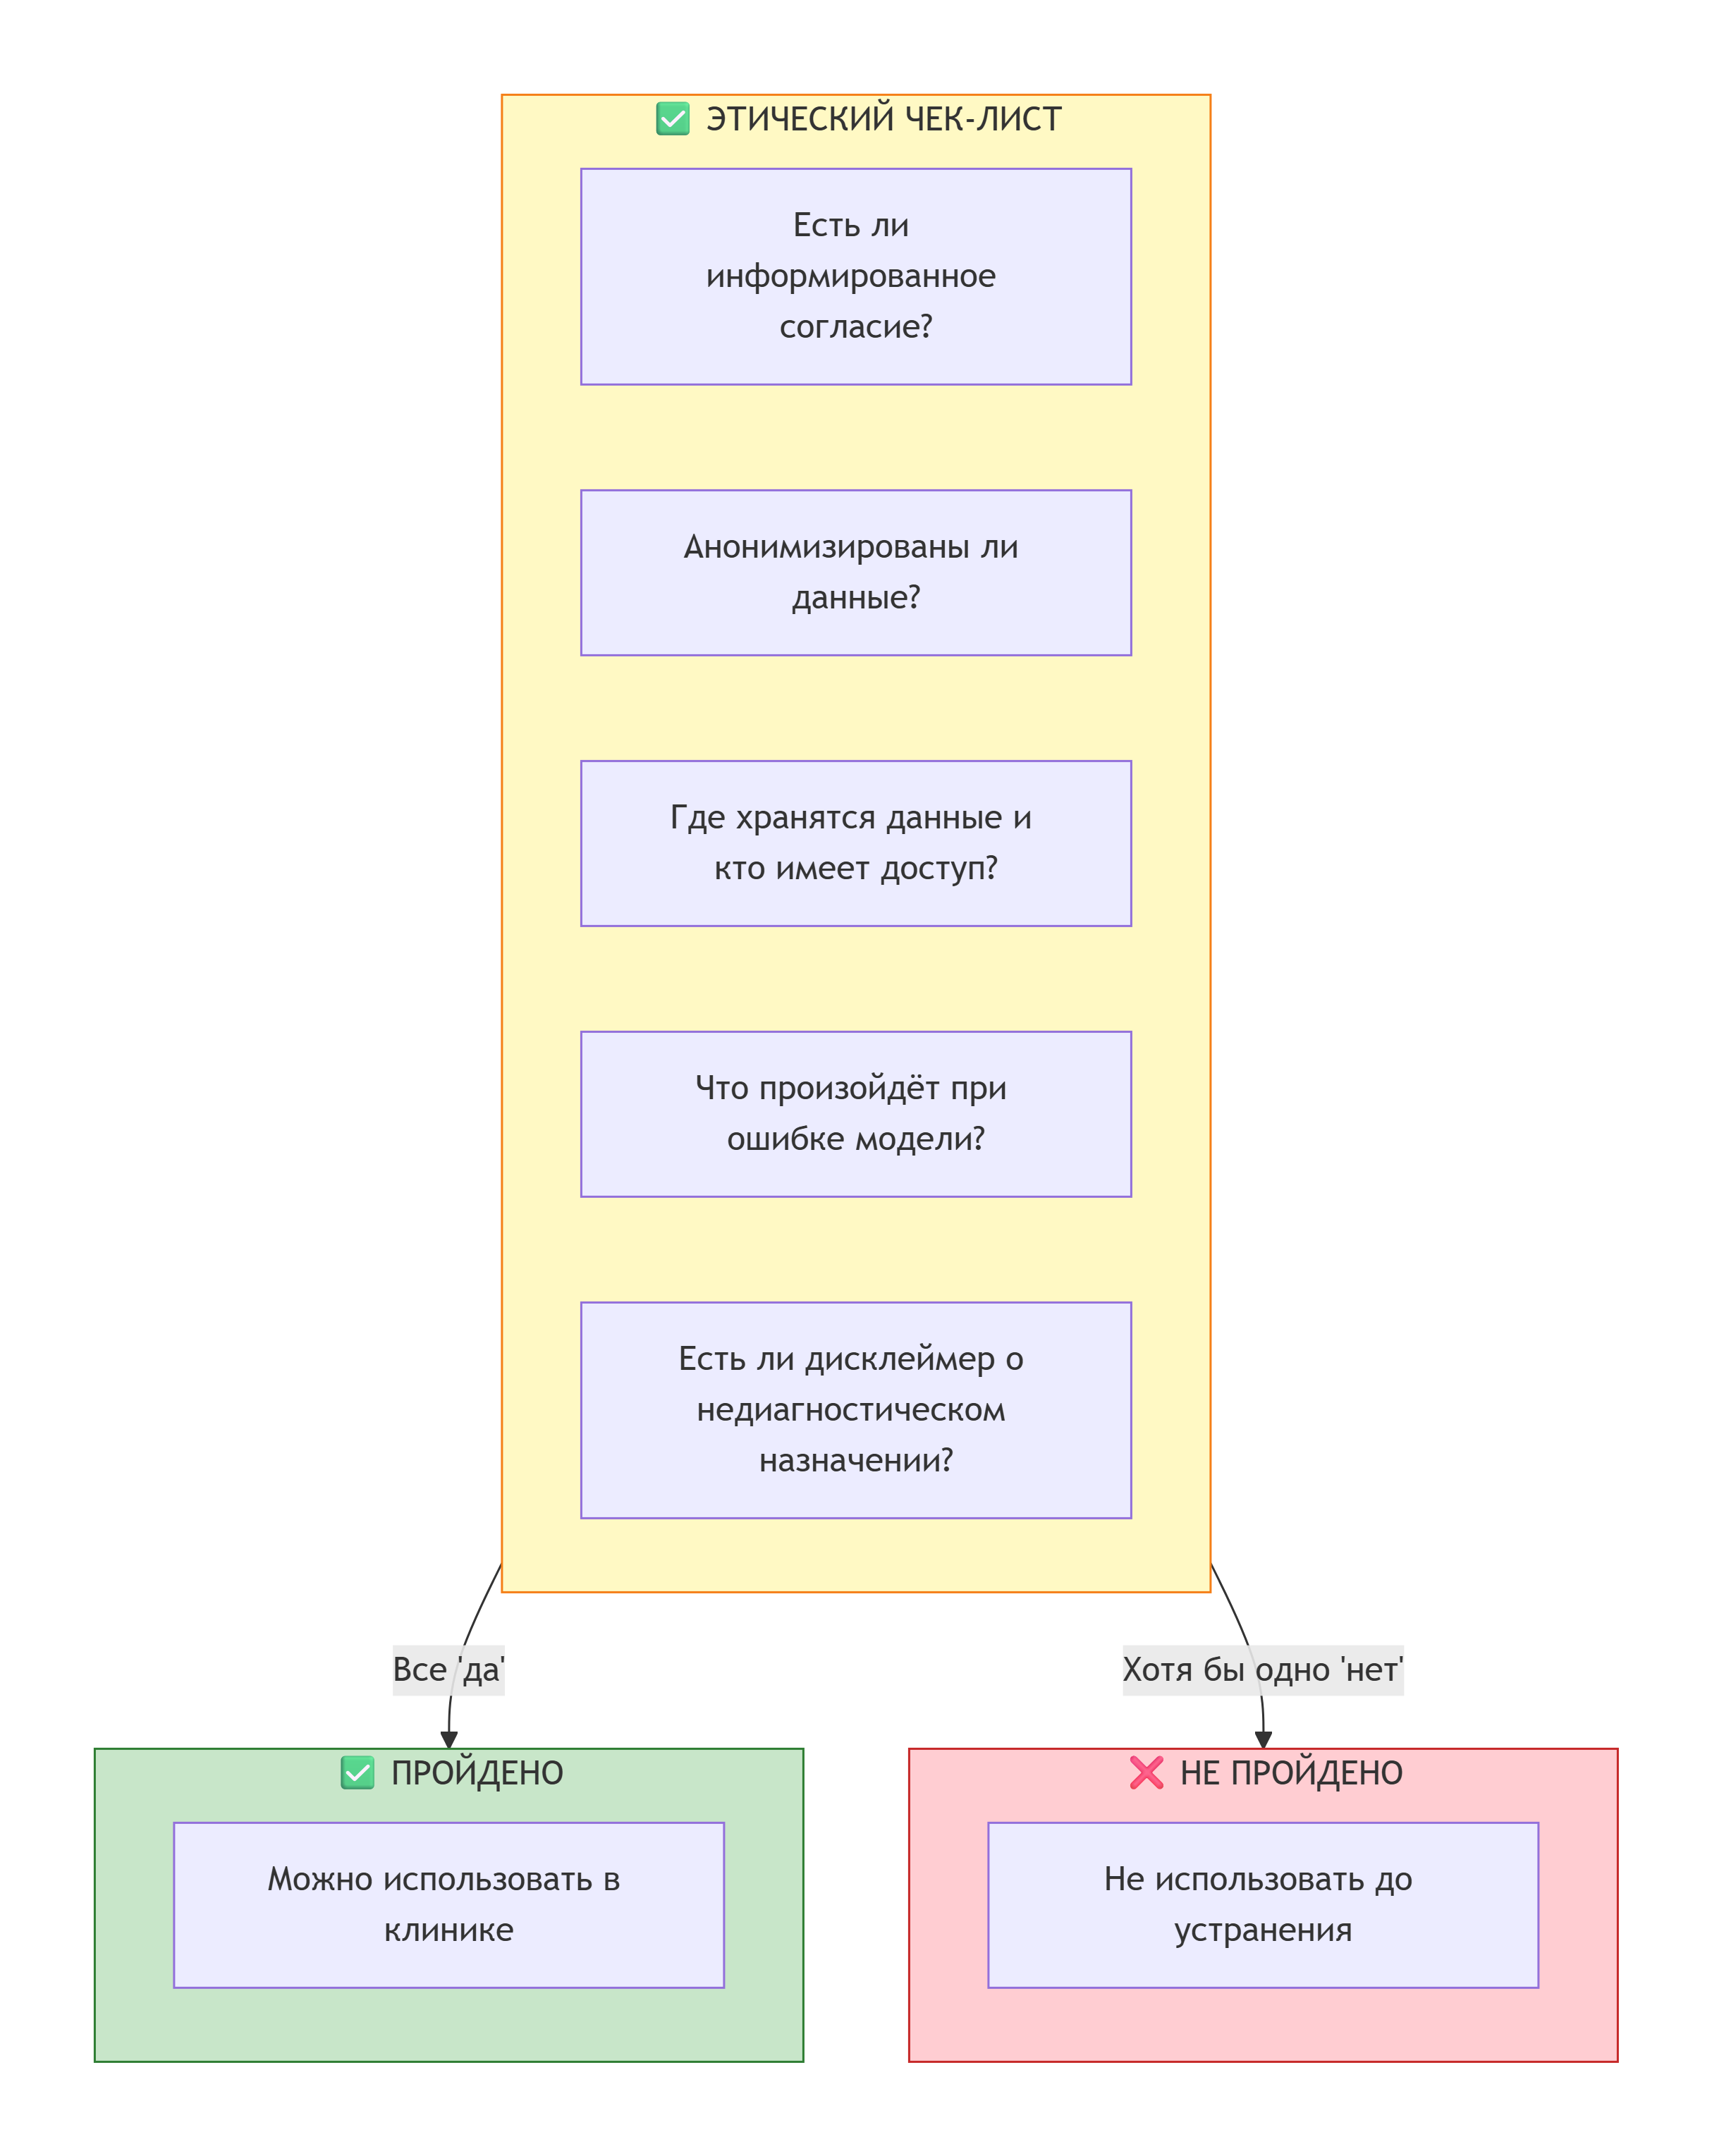


### 6.3. Пример дисклеймера для приложения

```markdown
⚠️ **ВАЖНОЕ ПРЕДУПРЕЖДЕНИЕ**

Это приложение — демонстрационный инструмент для образовательных целей.
Оно НЕ является медицинским диагностическим средством.

Результаты анализа:
• Не являются диагнозом
• Не заменяют консультацию специалиста
• Не должны использоваться для принятия клинических решений

Если вы испытываете психологические трудности, обратитесь к квалифицированному специалисту.

**Конфиденциальность:** Ваши данные не сохраняются на сервере.
```

### 6.4. Практические рекомендации

| Ситуация | Рекомендация |
|----------|--------------|
| **Демонстрация коллегам** | Используйте синтетические или анонимизированные данные |
| **Использование в клинике** | Только локальный деплой (не в облако) |
| **Исследовательский проект** | Получите одобрение этического комитета |
| **Публикация статьи** | Опишите все ограничения модели |
| **Обучение студентов** | Используйте открытые датасеты |
| **Личное использование** | Убедитесь, что данные не идентифицируют пациентов |



## 7. ЗАКЛЮЧЕНИЕ

### 7.1. Что мы сегодня узнали

| Что узнали | Ключевая идея | Практическое применение |
|------------|---------------|------------------------|
| **Зачем веб-интерфейс** | Превращает модель в доступный инструмент | Психолог может использовать модель без программирования |
| **Streamlit** | Python-фреймворк для веб-приложений без фронтенда | Создание клинических инструментов |
| **Gradio** | Альтернатива для быстрых демонстраций | Быстрый показ модели коллегам |
| **Проект от А до Я** | Установка → код → структура → запуск | Полный цикл создания приложения |
| **Облачный деплой** | Публикация приложения в интернете | Доступ для коллег и пациентов |
| **Этика** | Конфиденциальность, анонимизация, дисклеймер | Ответственное использование |

### 7.2. Ключевая мысль

> Модель — это ещё не инструмент. Инструмент появляется, когда у модели есть **интерфейс**, через который с ней может взаимодействовать человек. Streamlit позволяет **сделать этот шаг за несколько часов**, даже если вы никогда не занимались веб-разработкой.

### 7.3. Связь с будущим

- Вы уже умеете: очищать текст (Лекция 3), обучать модель (Практика 6), оценивать её (Лекция 6) и упаковывать в интерфейс (сегодня).
- Это **полный цикл** создания ИИ-инструмента для психологии.
- В следующих лекциях — применение этих инструментов в реальной клинической практике.

---

## 8. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ

1. Зачем психологу создавать веб-приложение для своей модели? Приведите три причины.

2. В чём основное различие между Streamlit и Gradio? В каком случае выбрать каждый?

3. Что делает `@st.cache_resource` и почему это важно для работы приложения?

4. Зачем нужен файл `requirements.txt` в проекте? Что произойдёт, если его не будет?

5. Назовите 3 компонента Streamlit для ввода данных и 3 для вывода результатов.

6. Что такое Hugging Face Inference API и как он упрощает создание приложений?

7. Опишите пошагово процесс деплоя на Streamlit Cloud.

8. Какие ограничения есть у бесплатного тарифа Streamlit Cloud? Как они влияют на выбор модели?

9. Почему нельзя загружать реальные данные пациентов в облачные сервисы без анонимизации?

10. Что должен содержать дисклеймер в психологическом ИИ-приложении?

11. **Этический вопрос:** представьте, что вы создали приложение для анализа эмоций. Ваш коллега хочет использовать его в клинике. Что вы ему посоветуете?

---

## 9. ДОМАШНЕЕ ЗАДАНИЕ (срок – 2 недели)

**Часть 1. Создание Streamlit-приложения (код + скриншоты)**

Возьмите модель из Практики 6 и создайте Streamlit-приложение по инструкции из лекции.

**Минимальные требования:**
- Заголовок и описание.
- Поле для ввода текста.
- Кнопка для запуска анализа.
- Вывод предсказанной эмоции.
- Прогресс-бар с уверенностью.
- График распределения вероятностей.
- Дисклеймер о недиагностическом назначении.

**Что сдать:**
1. Код `app.py`.
2. Скриншоты работающего приложения (3–4 шт.).
3. Краткое описание (1 стр.): какие компоненты использовали, с какими сложностями столкнулись.

---

**Часть 2. Подготовка к деплою (1–2 страницы)**

1. Создайте `requirements.txt` со всеми зависимостями.
2. Добавьте кеширование модели с `@st.cache_resource`.
3. Напишите краткую инструкцию по деплою (пошагово).

**Что сдать:**
1. Файл `requirements.txt`.
2. Инструкцию по деплою (1–2 стр.).
3. Ссылку на GitHub-репозиторий (если есть).

---

**Часть 3. Этический анализ (1–2 страницы)**

Представьте, что вы — руководитель психологического центра. Вы хотите внедрить Streamlit-приложение для анализа дневниковых записей пациентов.

Напишите **этический протокол**:
- Что должно быть в информированном согласии?
- Какие данные можно загружать, а какие — нет?
- Кто несёт ответственность за ошибки?
- Как организован человеческий контроль?

---

**Часть 4. Рефлексия (1 страница)**

Напишите эссе: *«Как я вижу использование веб-приложений в моей будущей психологической практике?»*

---

## 10. ЛИТЕРАТУРА

1. Streamlit Official Documentation (2024). *Streamlit for Data Science*. https://docs.streamlit.io
2. Gradio Official Documentation (2024). *Quickstart*. https://www.gradio.app/docs
3. Hugging Face Spaces Documentation (2024). *Getting Started with Spaces*. https://huggingface.co/docs/hub/spaces
4. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
5. Севостьянов, А. (2025). *Создание веб-приложений для психологических исследований на Streamlit*. Журнал цифровой психологии, 11(2), 34–42.
6. American Psychological Association. (2020). *Publication Manual of the American Psychological Association* (7th ed.).
7. GitHub Repository: Streamlit Examples for Psychology. https://github.com/streamlit/streamlit-example
